In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [ ]:
# Para instalar seaborn si no está instalado
#!pip install seaborn

# Para actualizar seaborn si tienen una versión anterior a 0.12.2
#!pip install seaborn --upgrade

In [4]:
# Verificar que tengamos la version 0.12.2 o superior
sns.__version__

'0.13.2'

# Visualización

## Seaborn objects y la gramática de gráficos

Introducido a finales de 2022, el nuevo sistema está basado el paradigma "Gramática de Gráficos" que utilizan otros paquetes como `ggplot2` de R.

No necesitamos recordar una docena de métodos para hacer gráficos, todo gráfico se hace mediante una única clase `Plot()`.

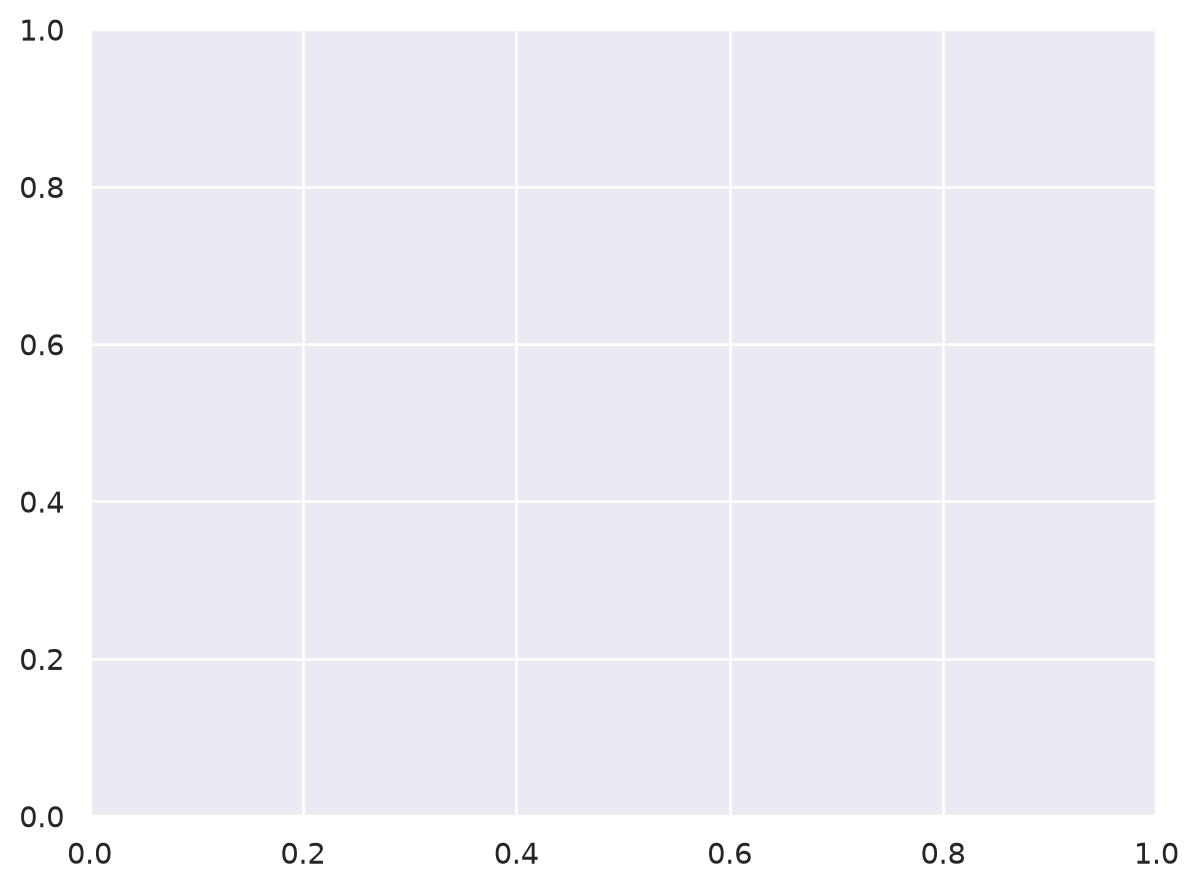

In [5]:
# Comenzamos con un gráfico vacío
so.Plot()

In [6]:
# Vamos a utilizar como primer ejemplo un dataset con el índice Dow Jones de las bolsas de Estados Unidos.
dowjones = sns.load_dataset("dowjones")
dowjones.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


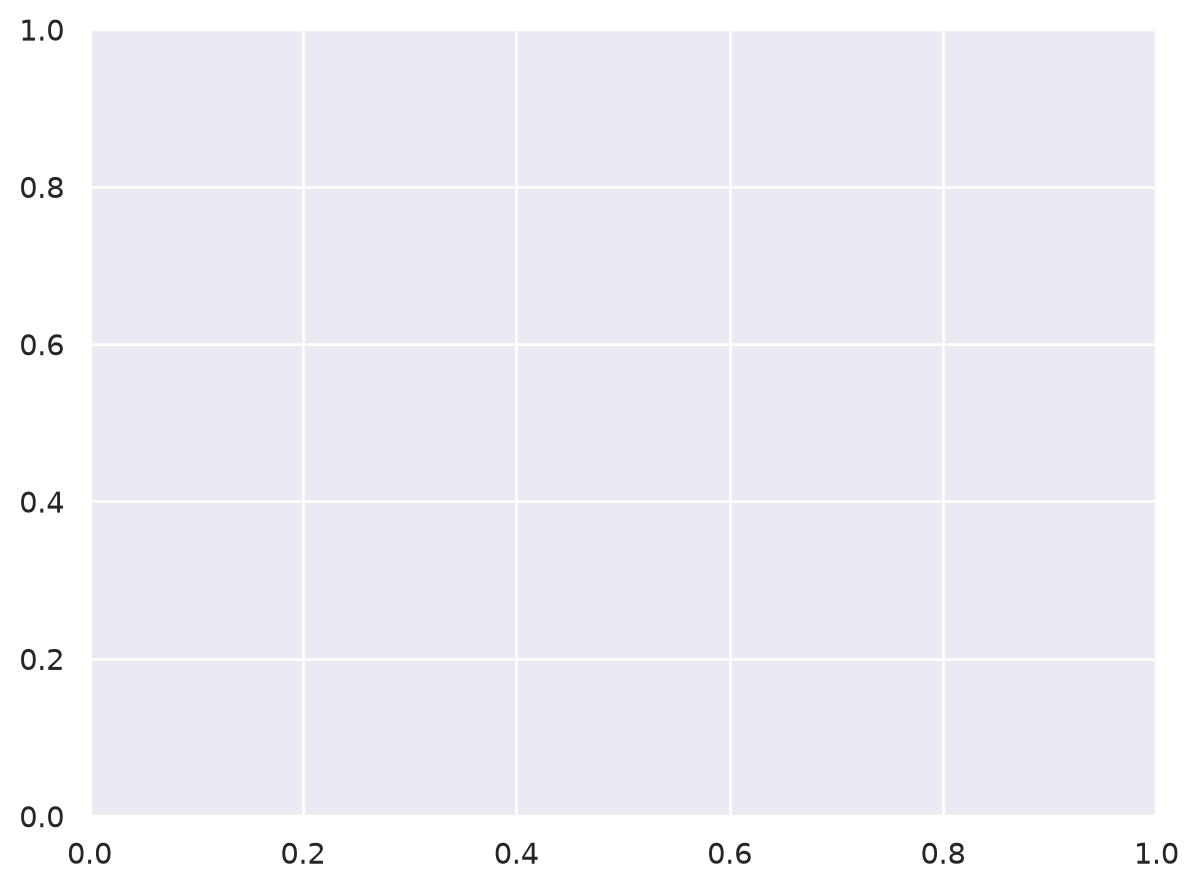

In [7]:
# Agregamos el conjunto de datos al Plot
so.Plot(data = dowjones)    # No se produce ningún cambio en el gráfico

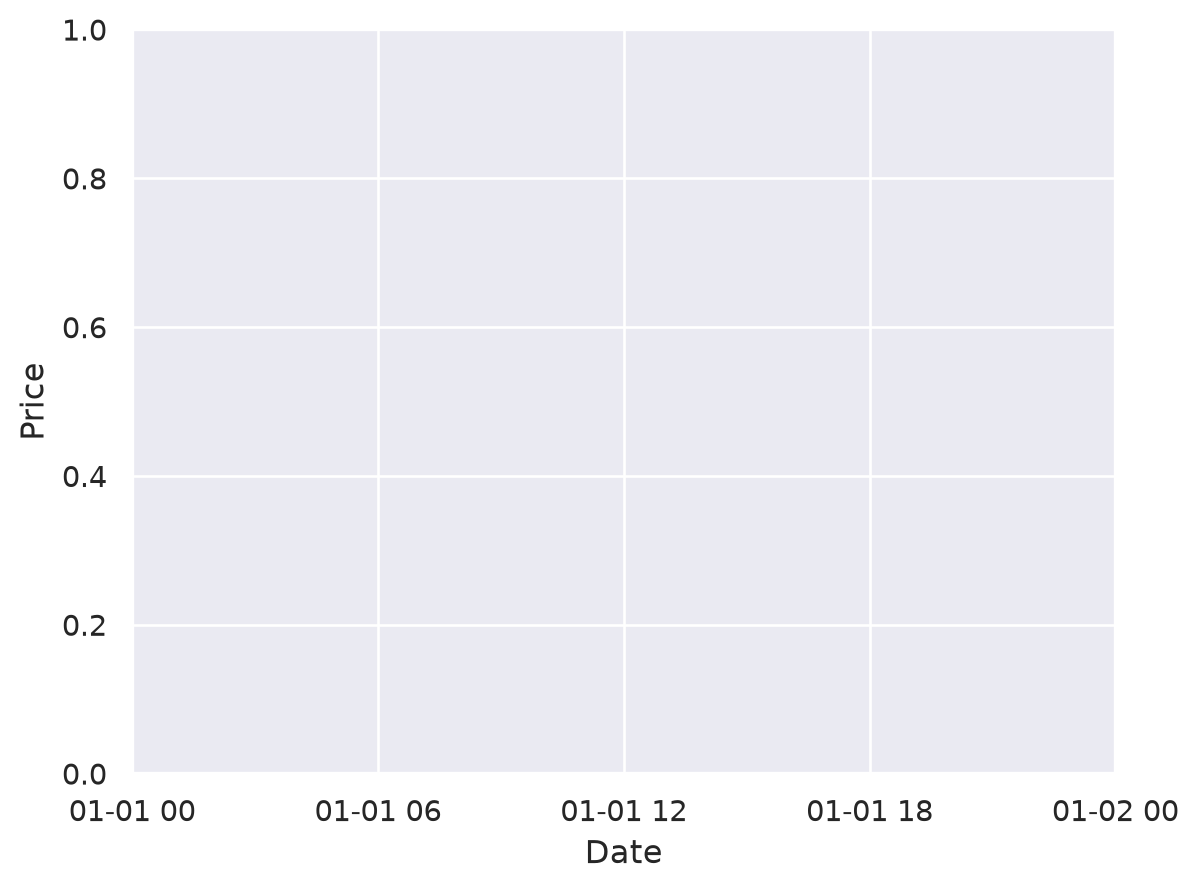

In [8]:
# Mapeamos la fecha al eje X y el precio al eje Y
so.Plot(data = dowjones, x = "Date", y = "Price")

## Gráfico de funciones

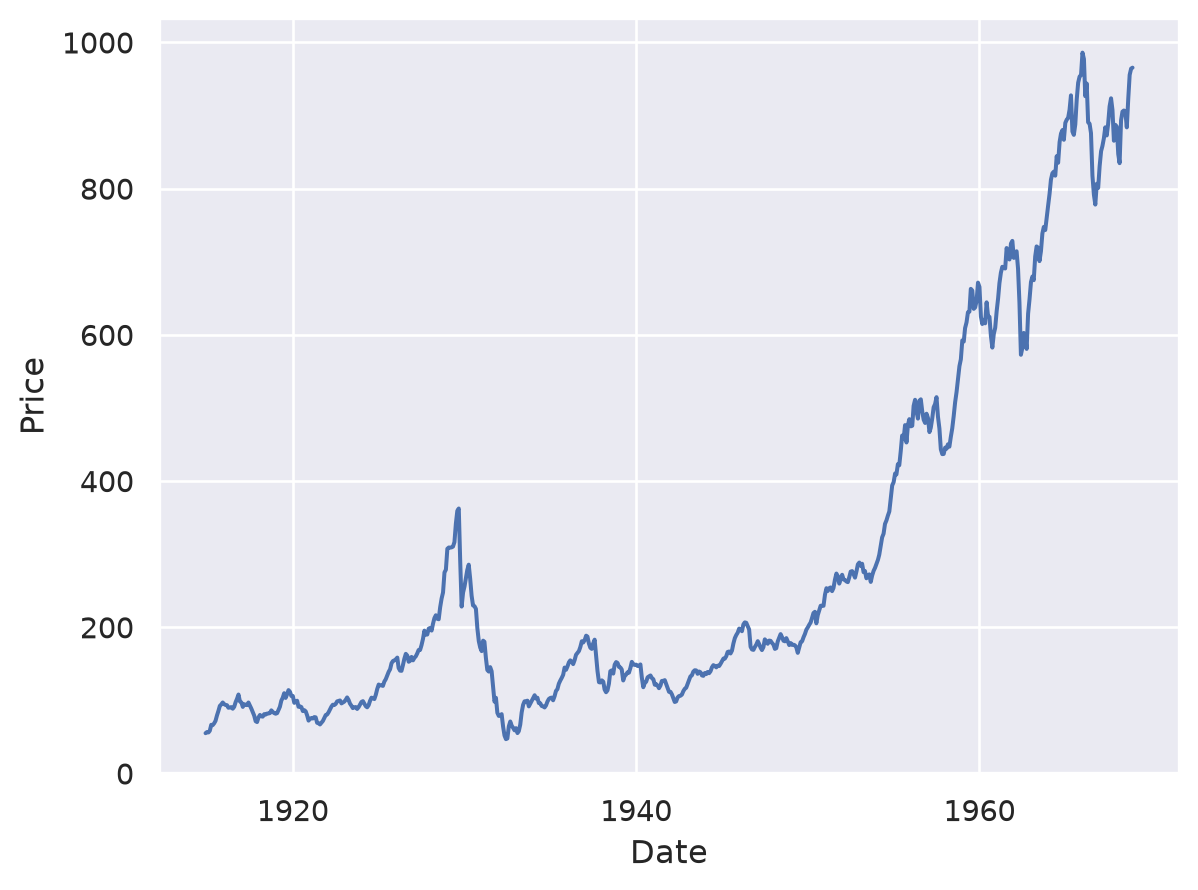

In [9]:
# Finalmente agregamos una marca, en este caso una curva.
# Usamos paréntesis para poder separar el comando en varias líneas y facilitar la lectura.
(
    so.Plot(data = dowjones, x = "Date", y = "Price")
    .add(so.Line())
)

## Gráfico de dispersión (scatter plot)
Utilizamos ahora una base de datos de propinas en restaurants.

Vamos a estudiar qué relación hay entre el valor de la cuenta y la propina que dejan los clientes.

In [10]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


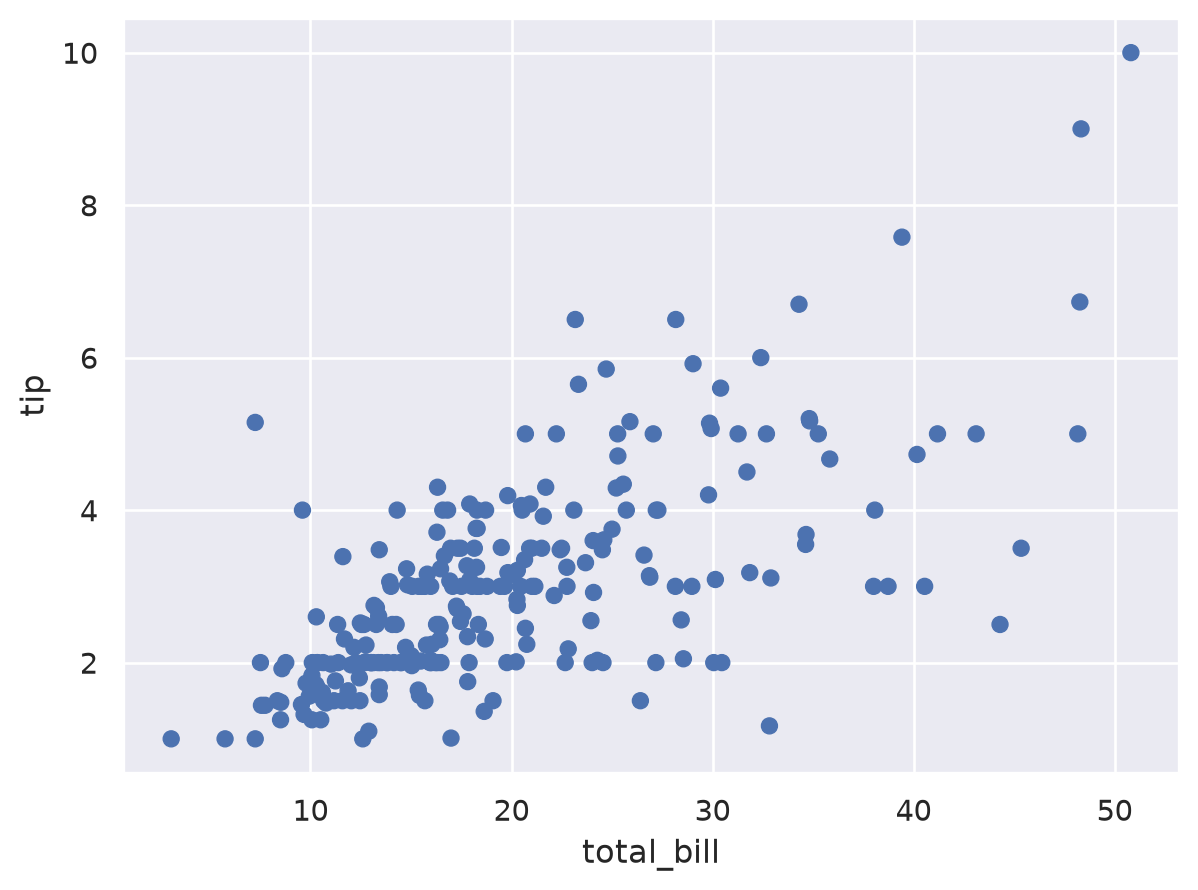

In [13]:
# Para usar puntos en vez de curvas, cambiamos la marca a Dot().
(
    so.Plot(data = tips, x = "total_bill", y = "tip")
    .add(so.Dot())
)

**Pregunta:** ¿tiene sentido para los datos de propinas realizar un gráfico de línea (conectando todos los puntos)?

No, porque va a ser un gráfico más engorroso que no aporta nada. Con un grafico de dispersión puedo ver cómodamente la tendencia de los datos.

## Gráfico de curvas y puntos?
En algunos casos queremos superponer líneas y puntos.

Utilizamos ahora una base de datos de cantidad de pasajeros mensuales en una aerolínea.

In [4]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


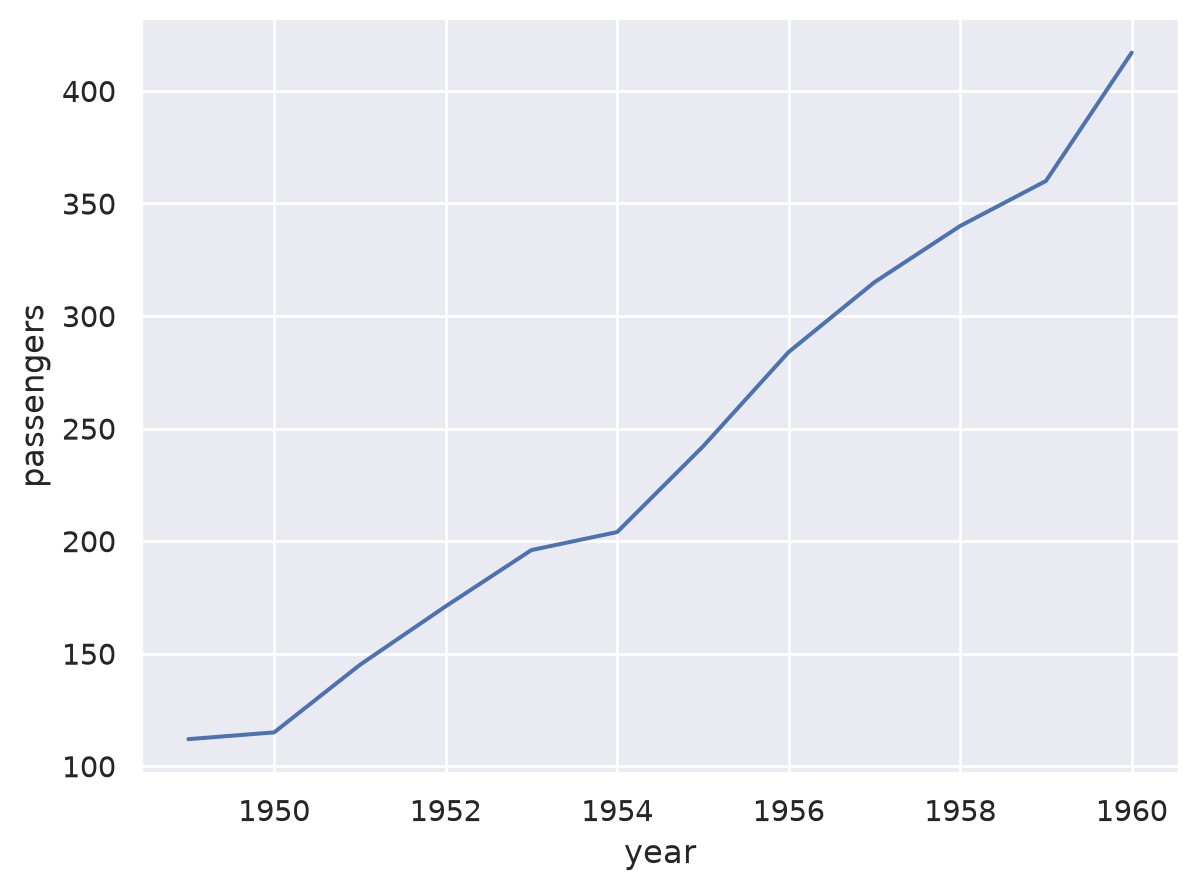

In [15]:
# Graficamos la curva cantidad de pasajeros en enero de cada año
vuelosEnero = flights[flights.month == "Jan"]
(
    so.Plot(data = vuelosEnero, x = "year", y = "passengers")
    .add(so.Line())
)

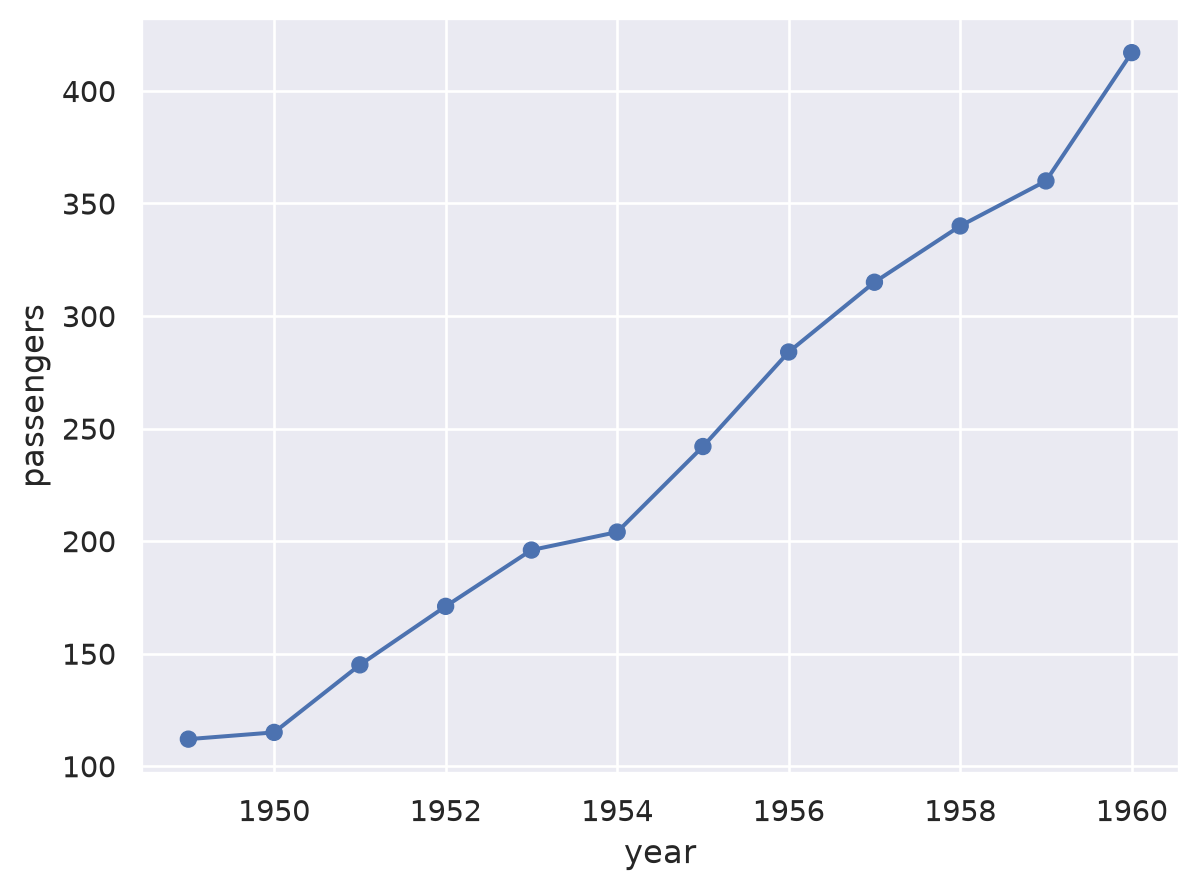

In [16]:
# Si queremos dibujar también los puntos correspondientes a cada dato...
(
    so.Plot(data = flights[flights.month == "Jan"], x = "year", y = "passengers")
    .add(so.Line())
    .add(so.Dot())
)

### Datos agrupados
¿Cómo podemos visualizar los datos de todos los meses, no solo enero?

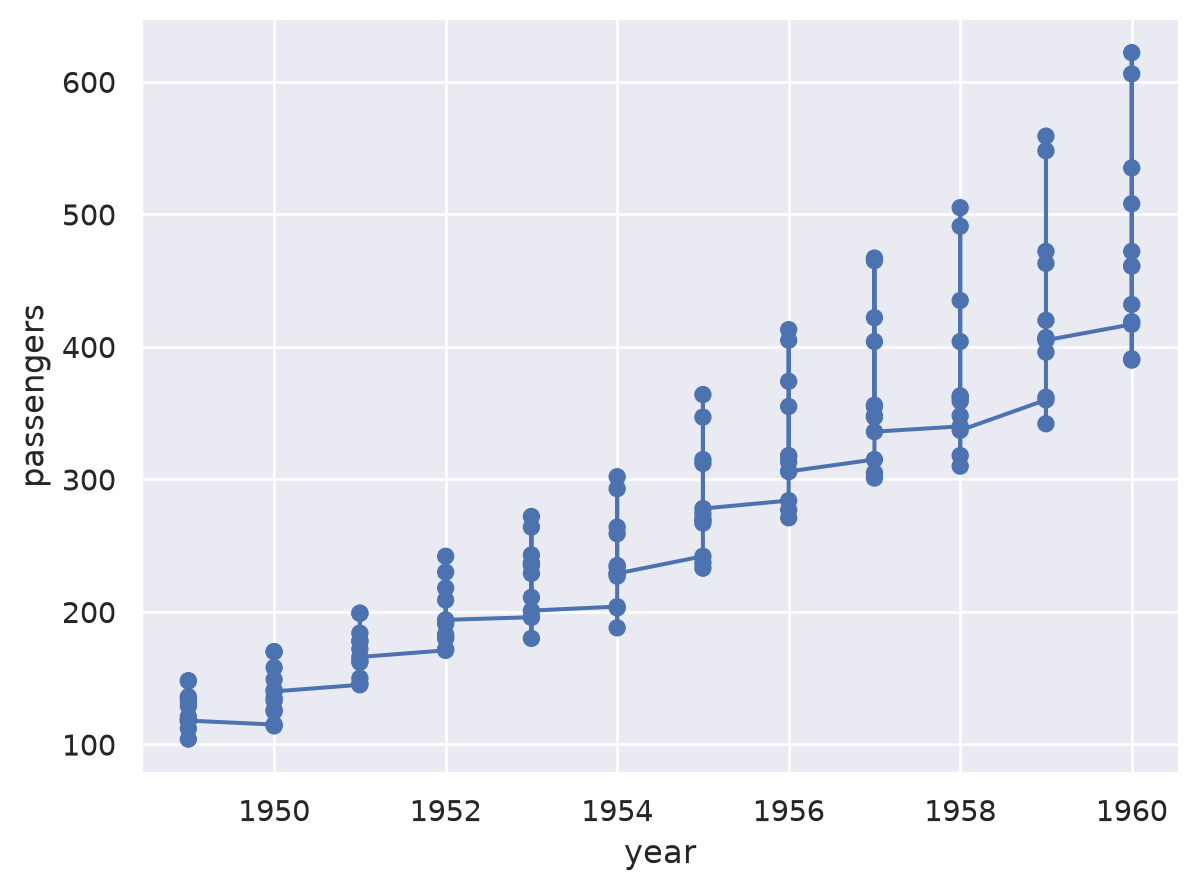

In [17]:
# Queremos considerar todos los meses. 
# Si sacamos el filtro...

(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Line())
    .add(so.Dot())
)

Un gráfico de curva no sirve cuando tenemos varios valores de y para un mismo valor de x.

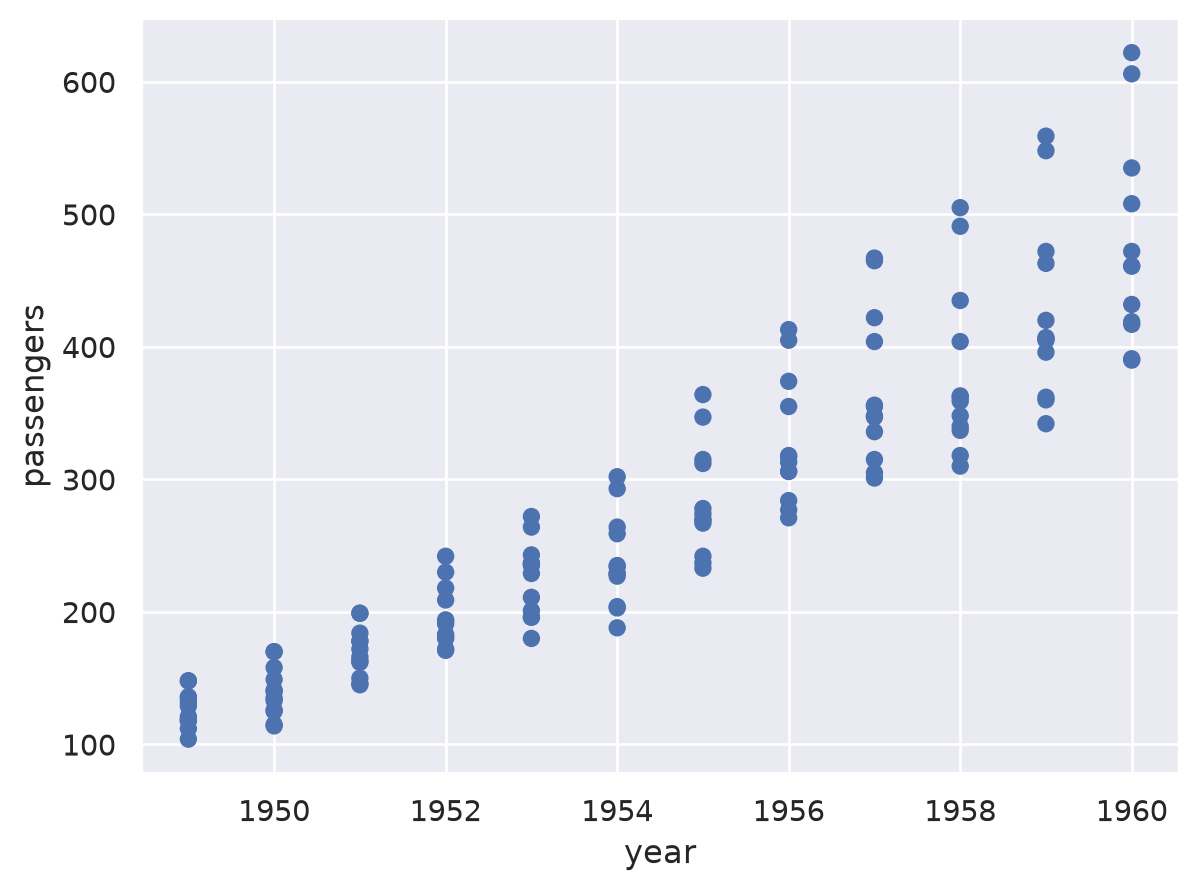

In [18]:
# Podemos dejar solo los puntos
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Dot())
)

Cómo podemos distinguir a que mes corresponde cada punto?

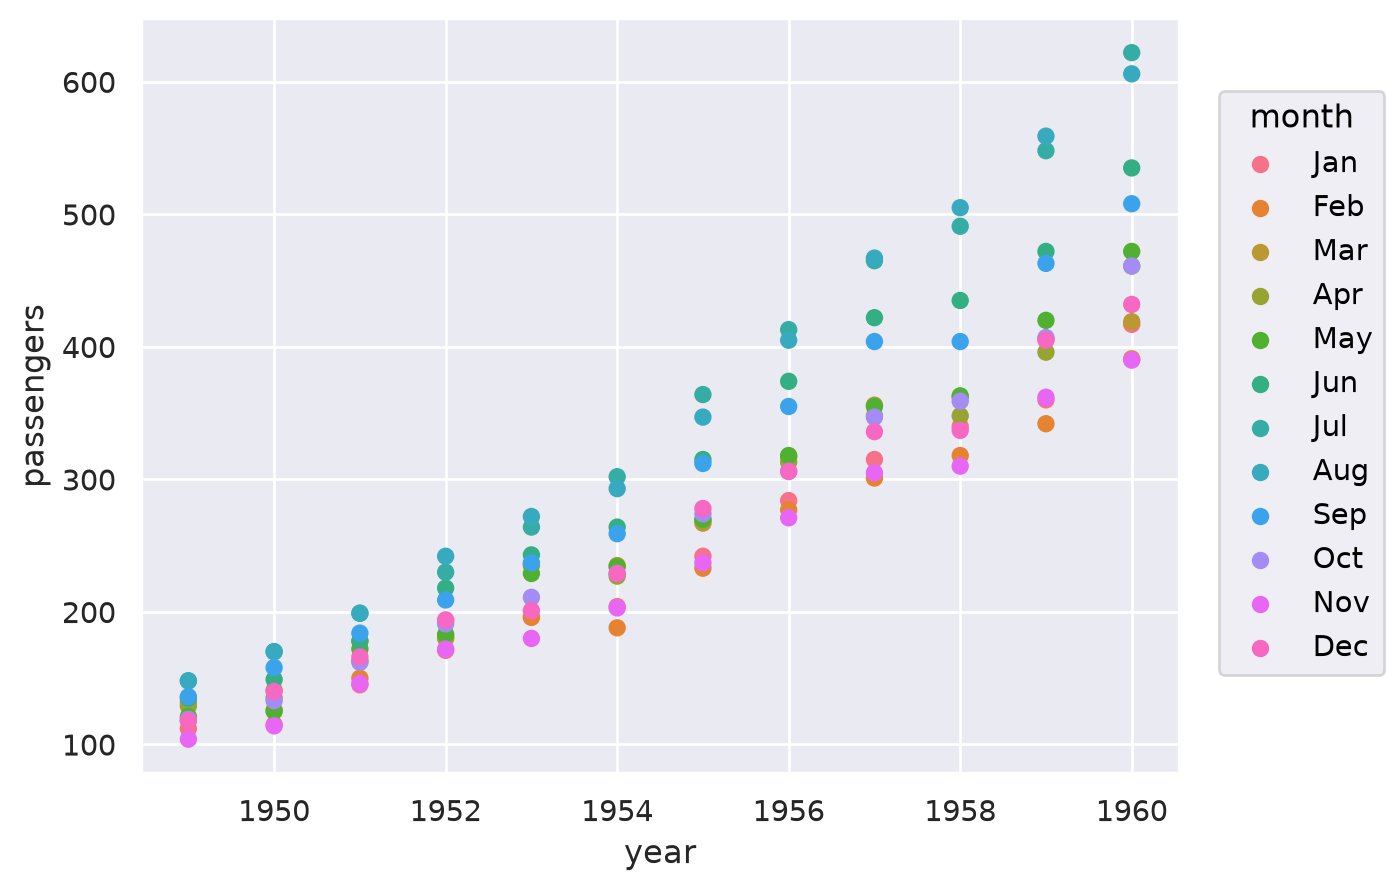

In [20]:
# Opción 1: utilizamos otro canal para codificar el mes
(
    so.Plot(data = flights, x = "year", y = "passengers", color = "month")
    .add(so.Dot())
)

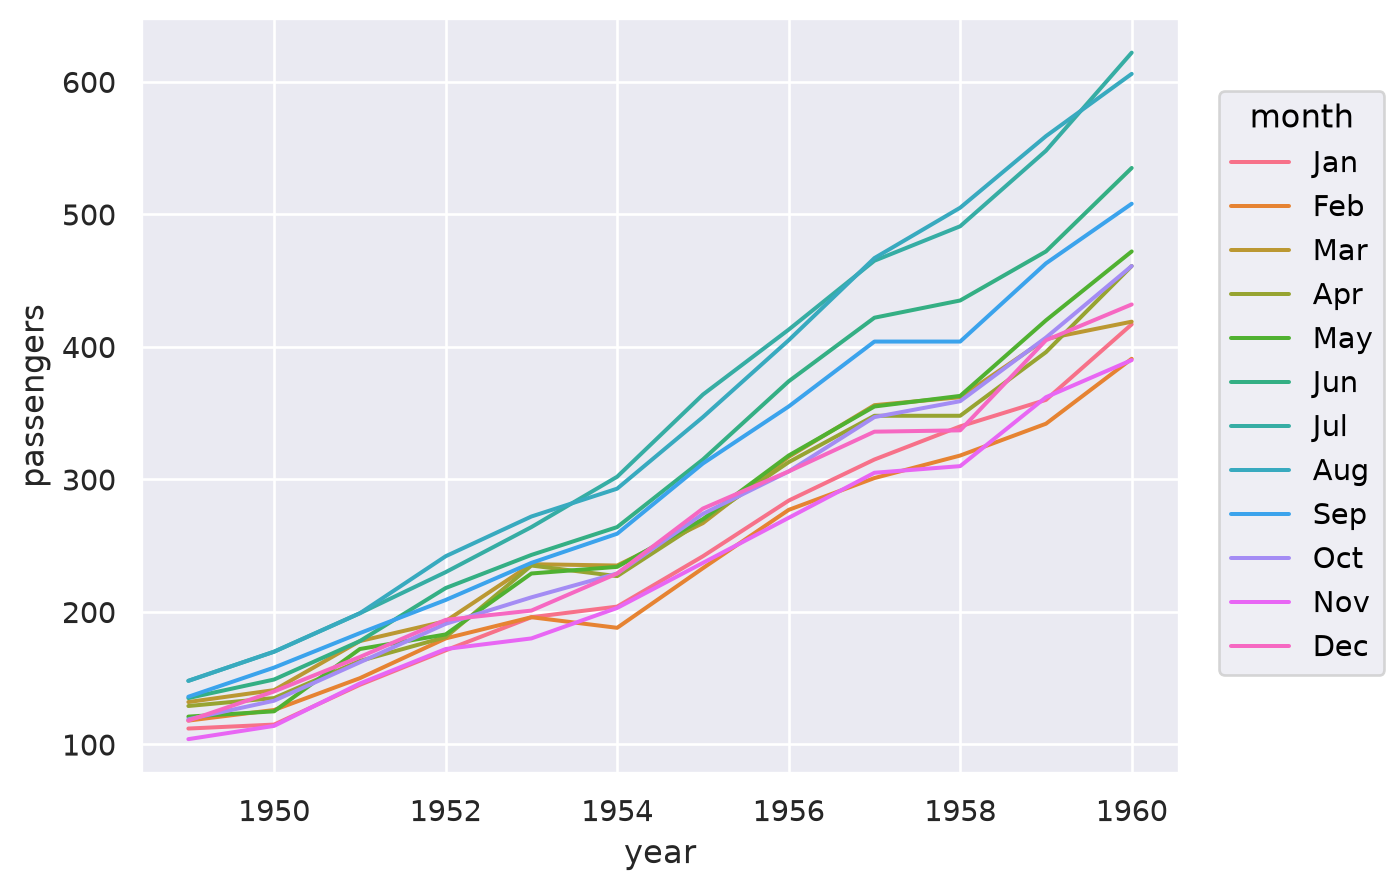

In [21]:
# Y si usamos líneas? En este caso, se agrupan automáticamente los valores por mes y se grafica una línea por mes 
# Es decir, color no solo pinta de color sino que también agrupa los datos según la variable indicada.
(
    so.Plot(data = flights, x = "year", y = "passengers", color = "month")
    .add(so.Line())
)

### Datos "agregados"

También podemos "agregar" datos (aggregate = agregar, juntar, resumir, ...)

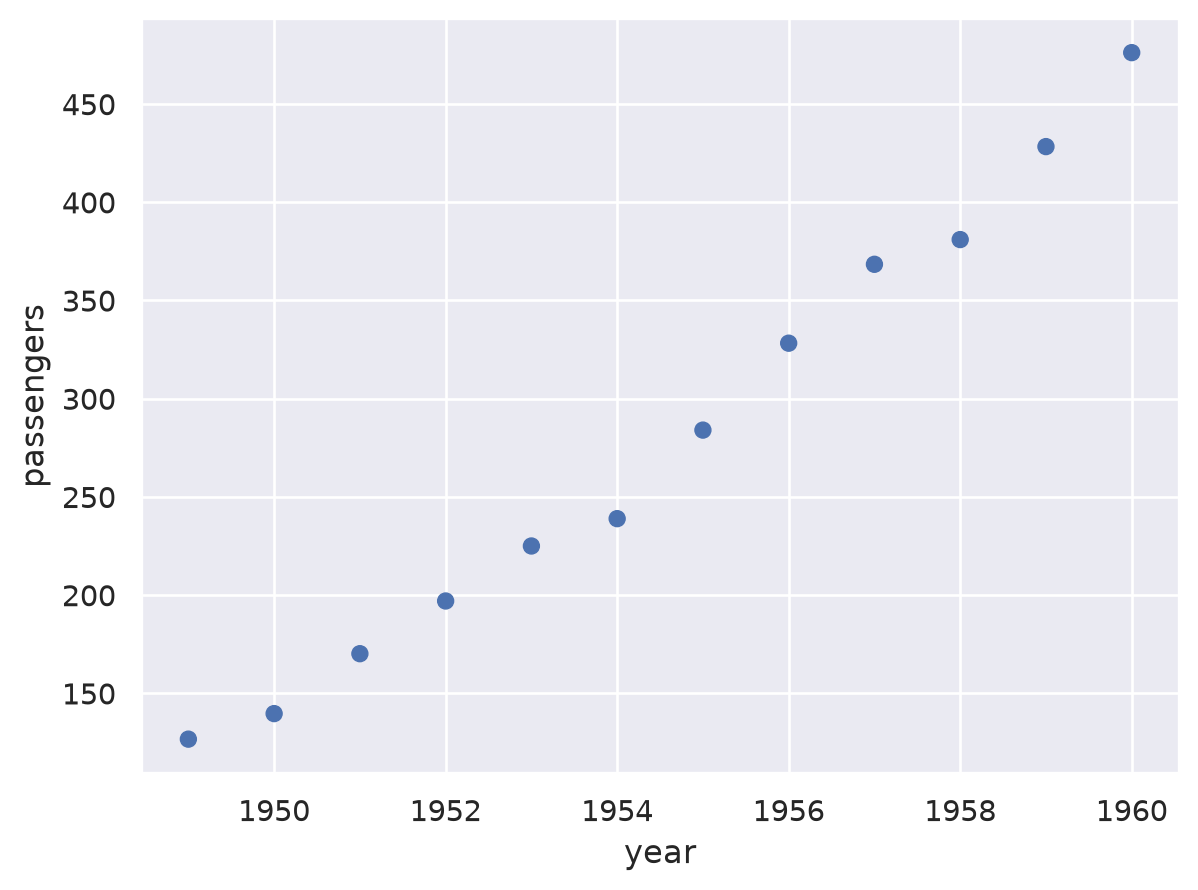

In [22]:
# Opción 2: agregamos los datos por mes
# Podemos calcularlos previamente utilizando lo que vimos en la práctica 2 (groupby(), sum(), ...)
# o usamos una función para agregar los datos.
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Dot(), so.Agg())  # Usamos .Agg para agregar los datos.
)

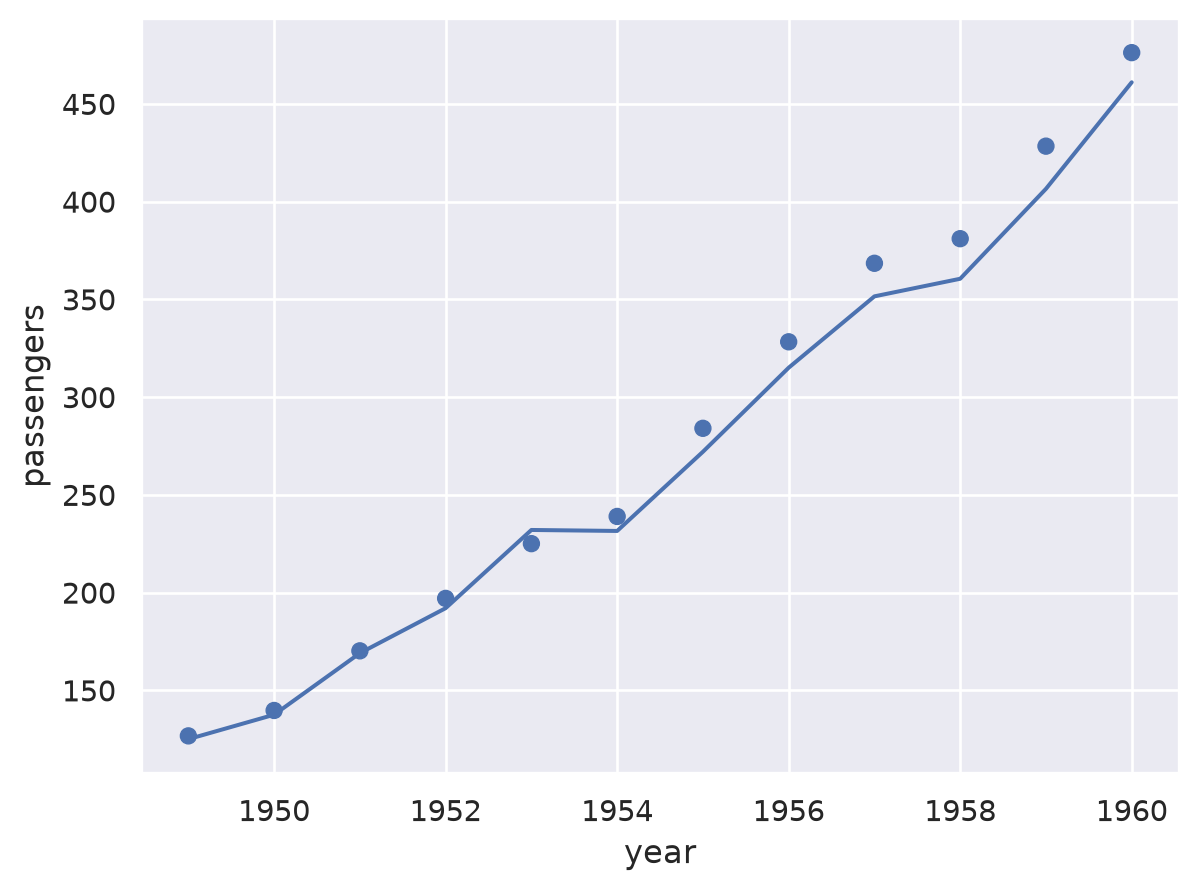

In [23]:
# Qué valores está graficando? Es la suma??
# Podemos indicar cualquier función de Pandas.Series para agregar los datos
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Dot(), so.Agg("mean"))
    .add(so.Line(), so.Agg("median"))
)

Otro canal común cuando hacemos gráficos de puntos es el tamaño de los puntos. 
¿Qué esperamos ver en el siguiente gráfico?

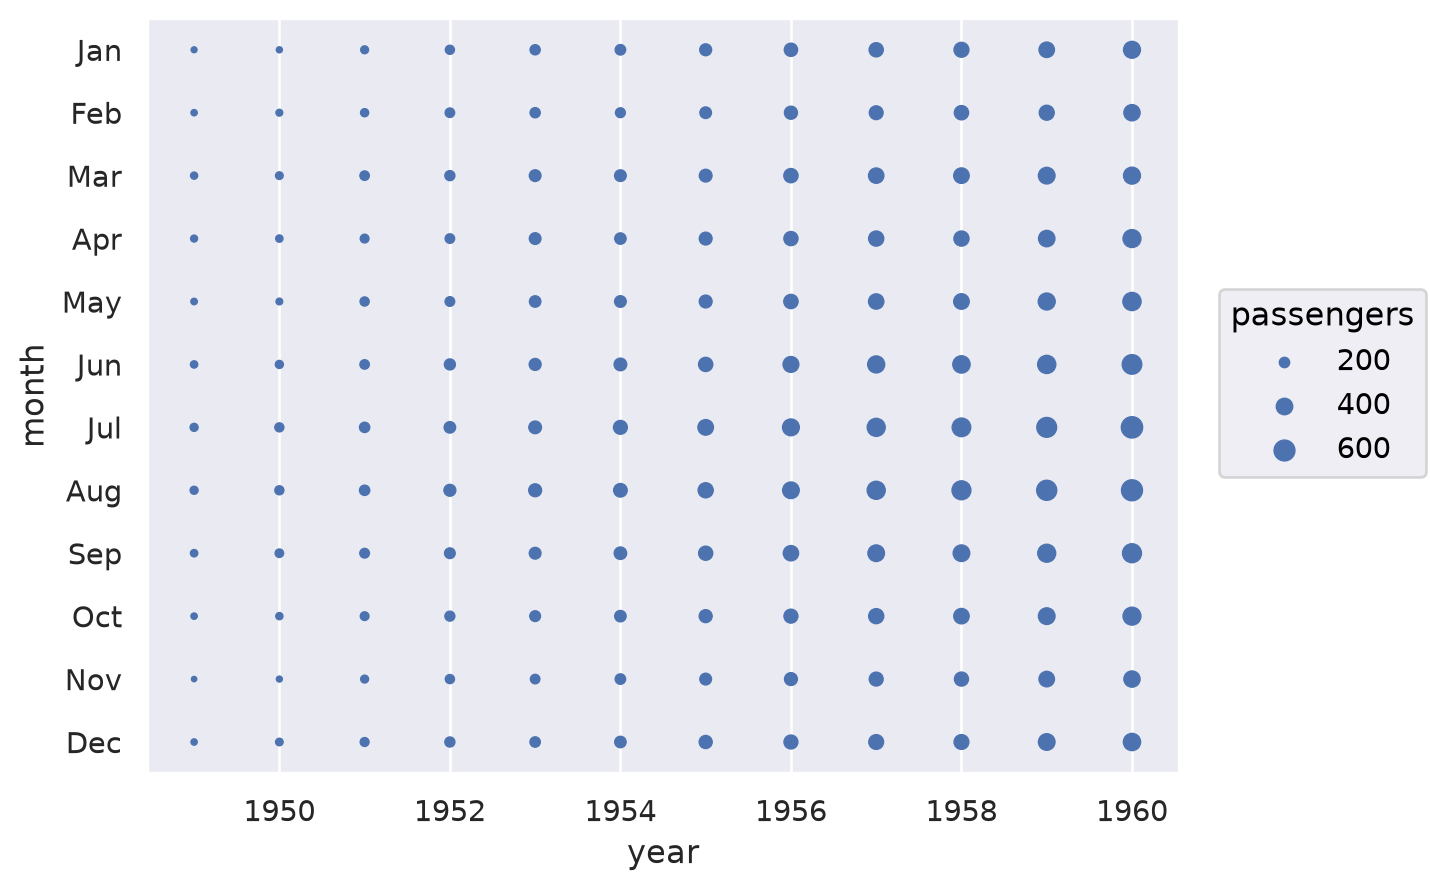

In [24]:
(
    so.Plot(data = flights, x = "year", y = "month", pointsize = "passengers")
    .add(so.Dot())
)

Más información sobre canales que podemos aplicar a puntos en la página
https://seaborn.pydata.org/tutorial/properties.html

### **Ejercicio**
Reproducir este gráfico utilizando Seaborn Objects.

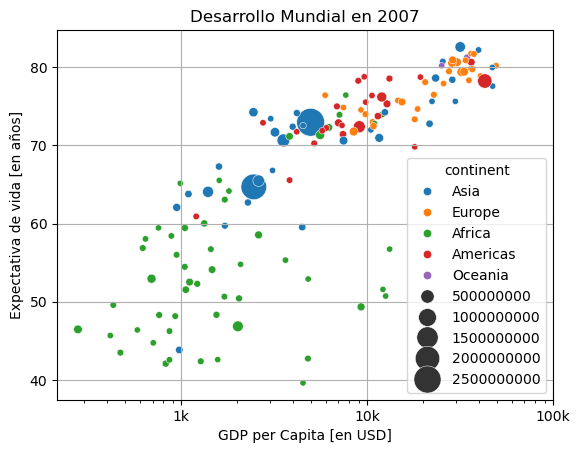

In [25]:
# Descarga de gapminder directo desde internet
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)
gapminder.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [40]:
data2007 = gapminder[gapminder["year"] == 2007] # me quedo con los datos de 2007
data2007

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


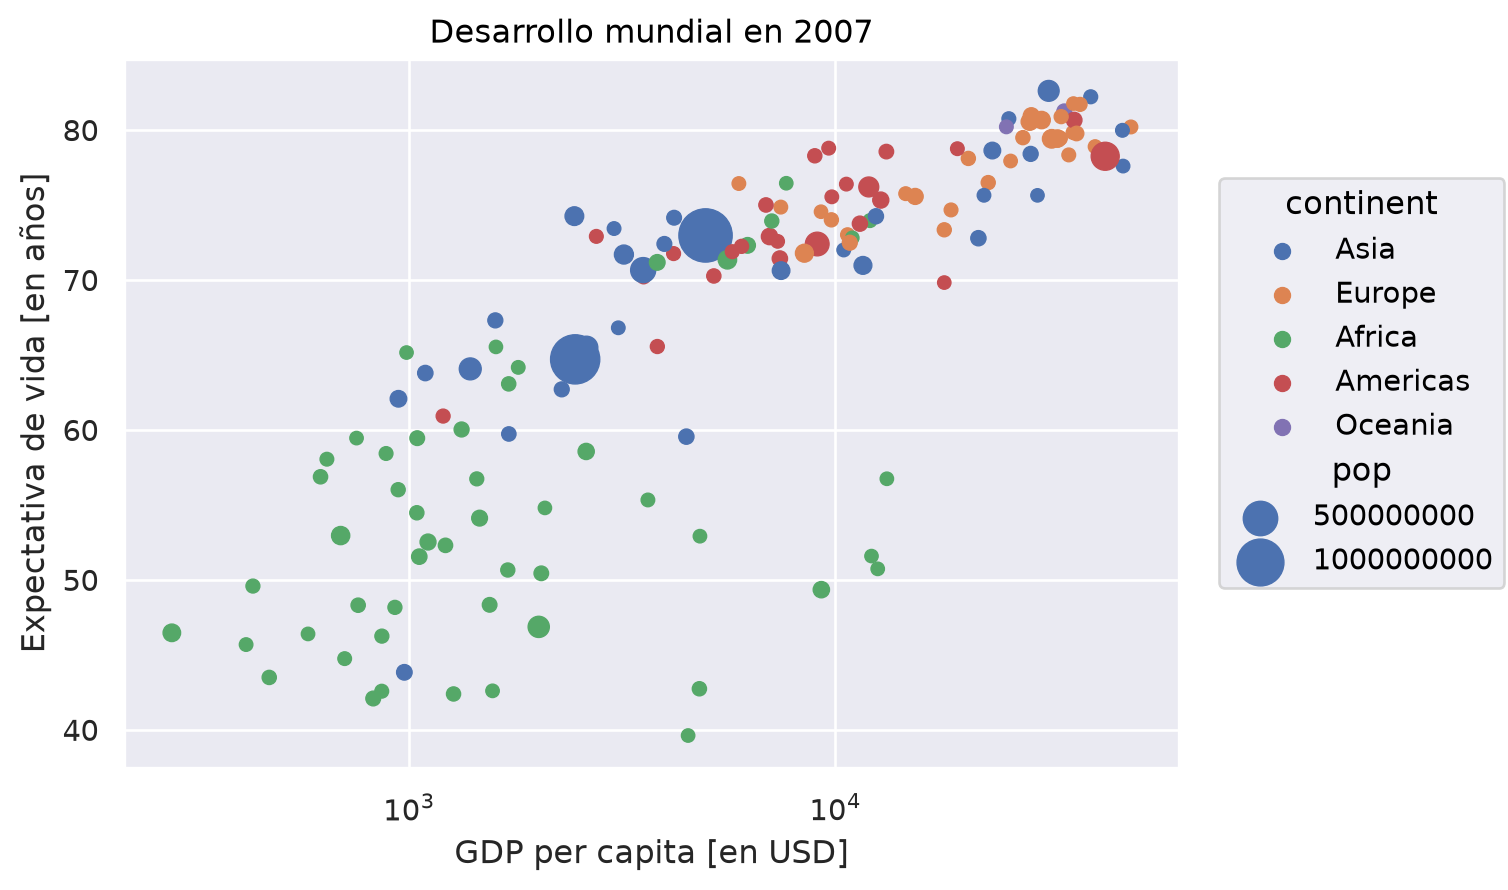

In [47]:
# En el eje X del grafico se usó escala logarítmica, podemos usar esa escala agrendo scale(x = "log")
(
    so.Plot(data = data2007, x = data2007["gdpPercap"], y = data2007["lifeExp"], color = "continent", pointsize = "pop")
    .add(so.Dot()).scale(x="log", pointsize=(5, 20))  # Escala logaritmica en la variable x y tamaño de puntos entre 5 y 20.
    .label(
        x = "GDP per capita [en USD]", 
        y = "Expectativa de vida [en años]",
        title = "Desarrollo mundial en 2007"
    )
)


### **Ejercicio**

El dataset mpg de Seaborn tiene información sobre la eficiencia (miles per gallon) de distintos modelos de autos.
Realizar un gráfico que permita visualizar como inciden el país de origen, el peso del auto y los caballos de fuerza en la eficiencia del auto.

¿Qué conclusiones podemos sacar en base a este gráfico?

In [48]:
# Cargamos los datos
mpg = sns.load_dataset("mpg")
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


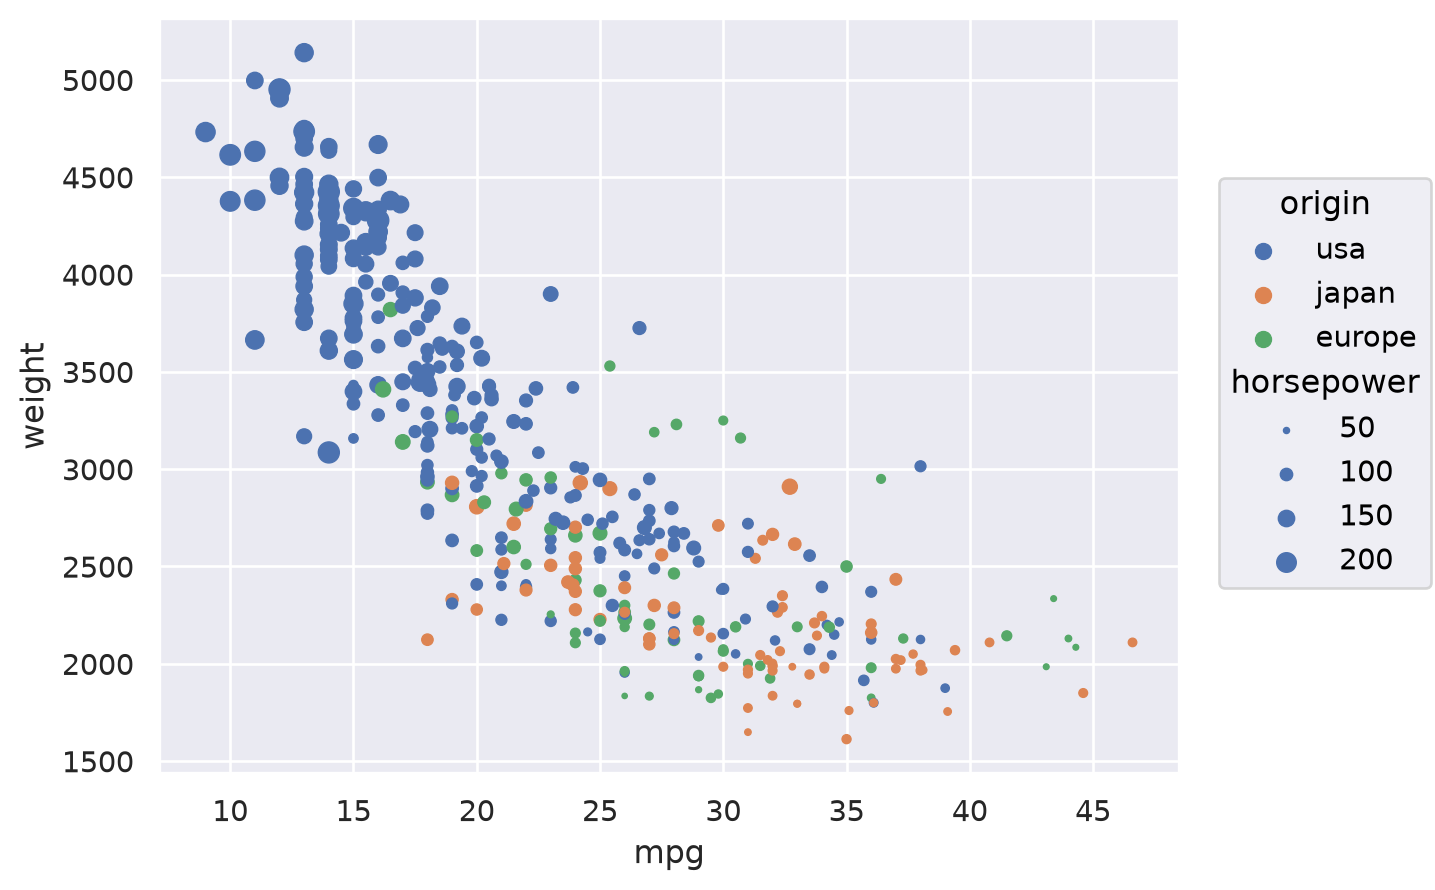

In [53]:
(
    so.Plot(data = mpg, x = "mpg", y = "weight", color = "origin", pointsize = "horsepower")
    .add(so.Dot())
)

Viendo el gráfico puedo concluir que los autos de mayor eficiencia (mpg, miles per gallon) son los mas ligeros (de menor peso, weight) y los que a su vez tienen menos caballos de fuerza (horsepower), con una tendencia a que sean autos provenientes de Europa o Japon. 

## Mapeo y asignación por capas

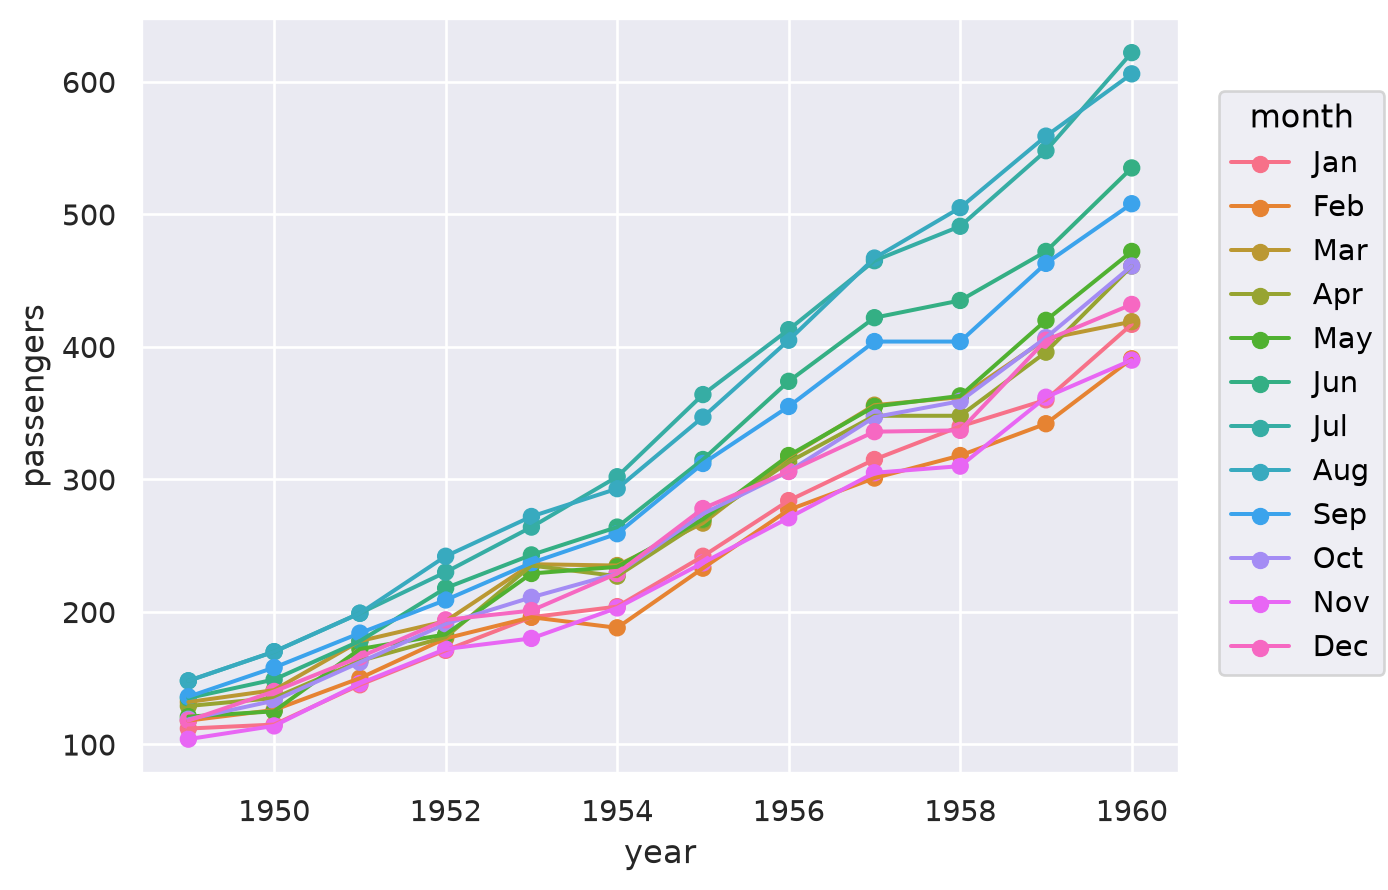

In [54]:
# Podemos asignar una codificación al definir el Plot() y esa codificación para a todas las capas.
(
    so.Plot(data = flights, x = "year", y = "passengers", color = "month")
    .add(so.Line())
    .add(so.Dot())
)

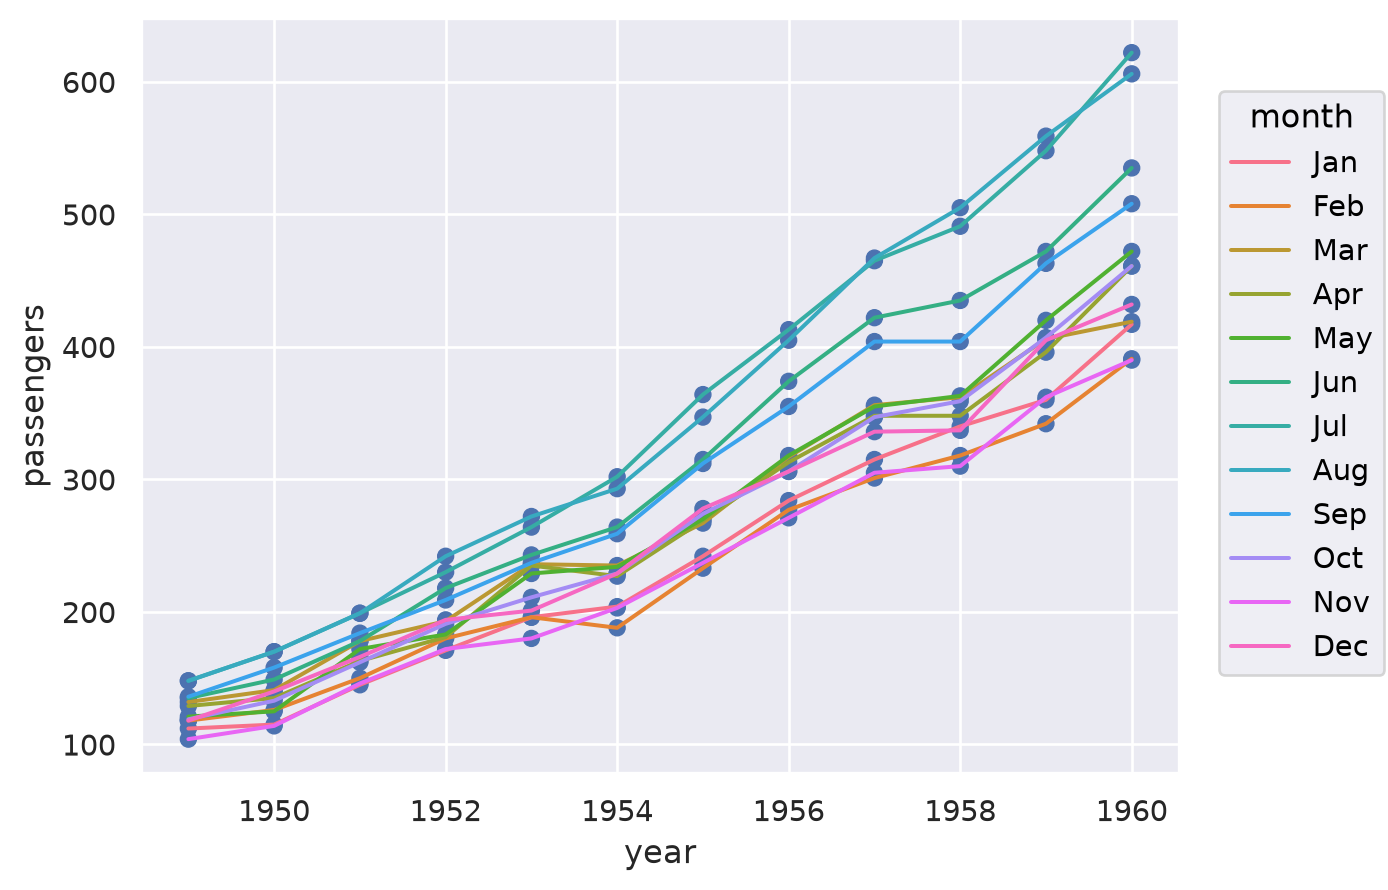

In [55]:
# O podemos asignar una codificación al agregar una marca y esa codificación se aplica solo en esa capa.
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Line(), color = "month")
    .add(so.Dot())
)

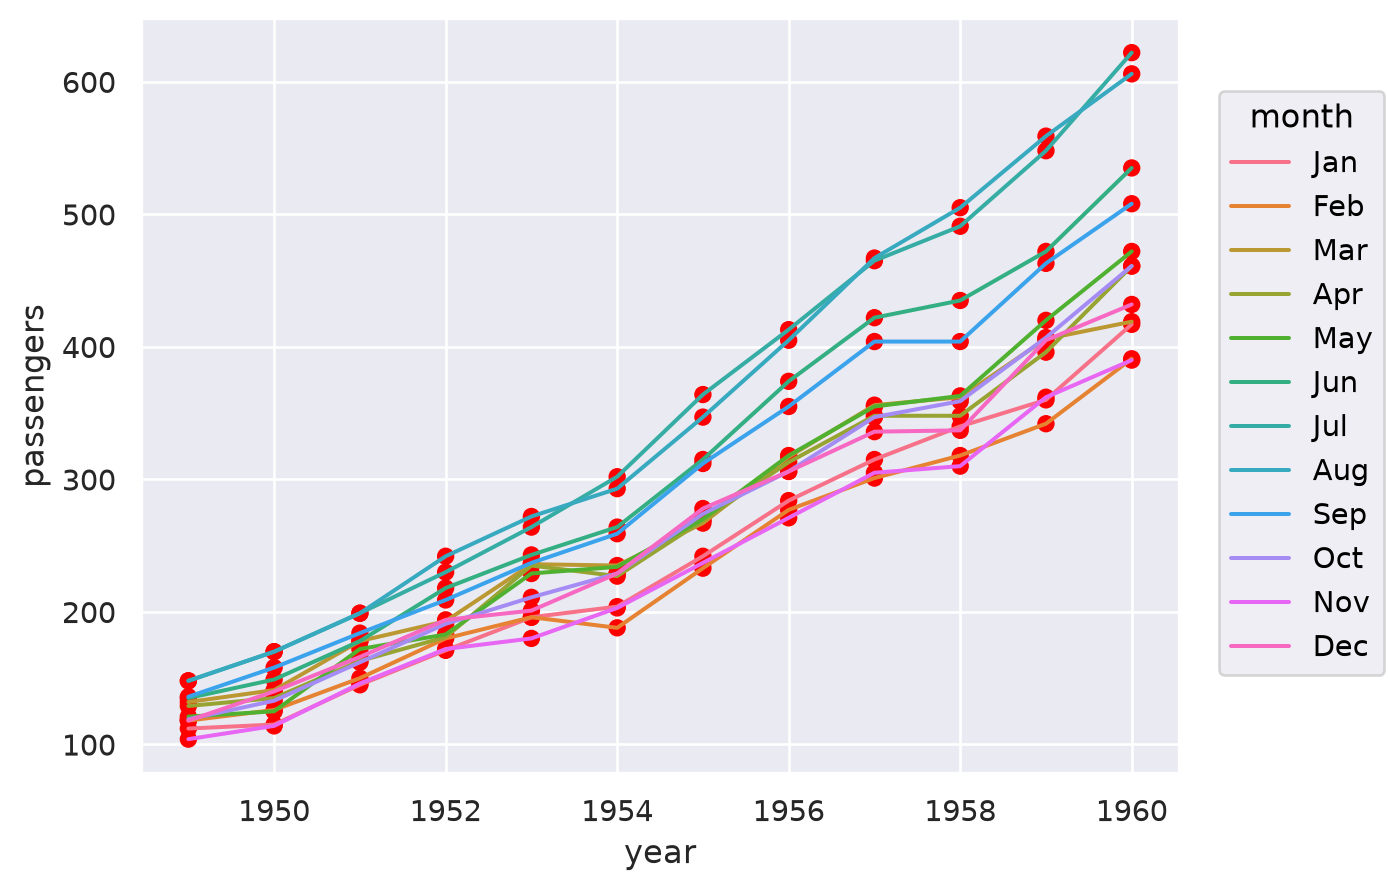

In [56]:
# Si asignamos un pámatetro a la marca Dot() u otra marca, no estamos codificando datos sino que asignamos el valor directamente.
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Line(), color = "month")
    .add(so.Dot(color = "red"))
)


### **Ejercicio** 
¿Que pasa si hacemos `.add(so.Dot(color = "month"))`? --> Da error porque esta notación es exclusiva para darle un color a los puntos. No es como cuando pongo "color = "month"" en so.Plot(), en donde estoy identificacndo una variable con un color.

¿Y si hacemos `so.Plot(data = flights, x = "year", y = "passengers", color = "red")`? --> También da error porque esta notación es para identificar una variable con un color. El "color = ..." que tengo que poner en el so.Plot() tiene que ser con una variable (una columna) que esté en el dataframe de data.

In [58]:
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Line(), color = "month")
    .add(so.Dot(color = "month"))
)

ValueError: Invalid RGBA argument: 'month'

In [59]:
(
    so.Plot(data = flights, x = "year", y = "passengers", color = "red")
    .add(so.Line(), color = "month")
    .add(so.Dot())
)

ValueError: Could not interpret value `red` for `color`. An entry with this name does not appear in `data`.

La codificación de datos en las coordenadas x e y de las marcas también podemos indicarlas en las capas y codificar distintos datos en distintas capas.

### **Notación:** 
Si utilizamos una palabra entre comillas para algún canal, se interpreta como una variable del DataFrame. 
Si lo hacemos sin comillas se interpreta como una variable fuera del DataFrame, podemos usar por ejemplo arrays de numpy o series de pandas.

In [60]:
# Si queremos comparar la cantidad promedio de vuelos con la cantidad de vuelos en enero...
pasajerosEnero = flights[flights["month"] == "Jan"]["passengers"]
display(pasajerosEnero)

0      112
12     115
24     145
36     171
48     196
60     204
72     242
84     284
96     315
108    340
120    360
132    417
Name: passengers, dtype: int64

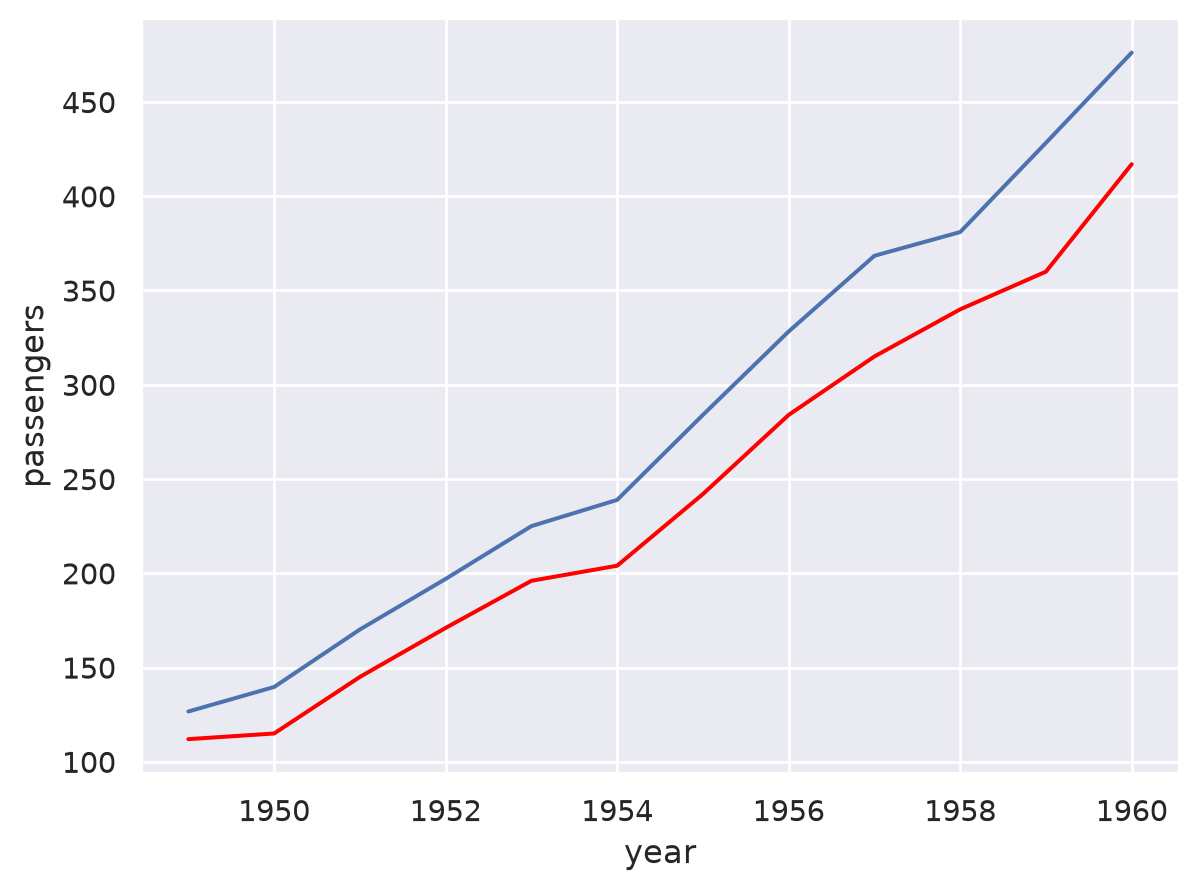

In [62]:
# Si queremos comparar la cantidad promedio de vuelos con la cantidad de vuelos en enero...
(
    so.Plot(data = flights, x = "year")
    .add(so.Line(), so.Agg("mean"), y = "passengers") # Promedio anual de pasajeros por mes
    .add(so.Line(color = "red"), y = pasajerosEnero) # Pasajeros en enero
)

Con este gráfico puedo ver cómo la cantidad de pasajeros en enero siempre es menor a la cantidad de pasajeros promedio de todo el año.

## Gráficos de barras

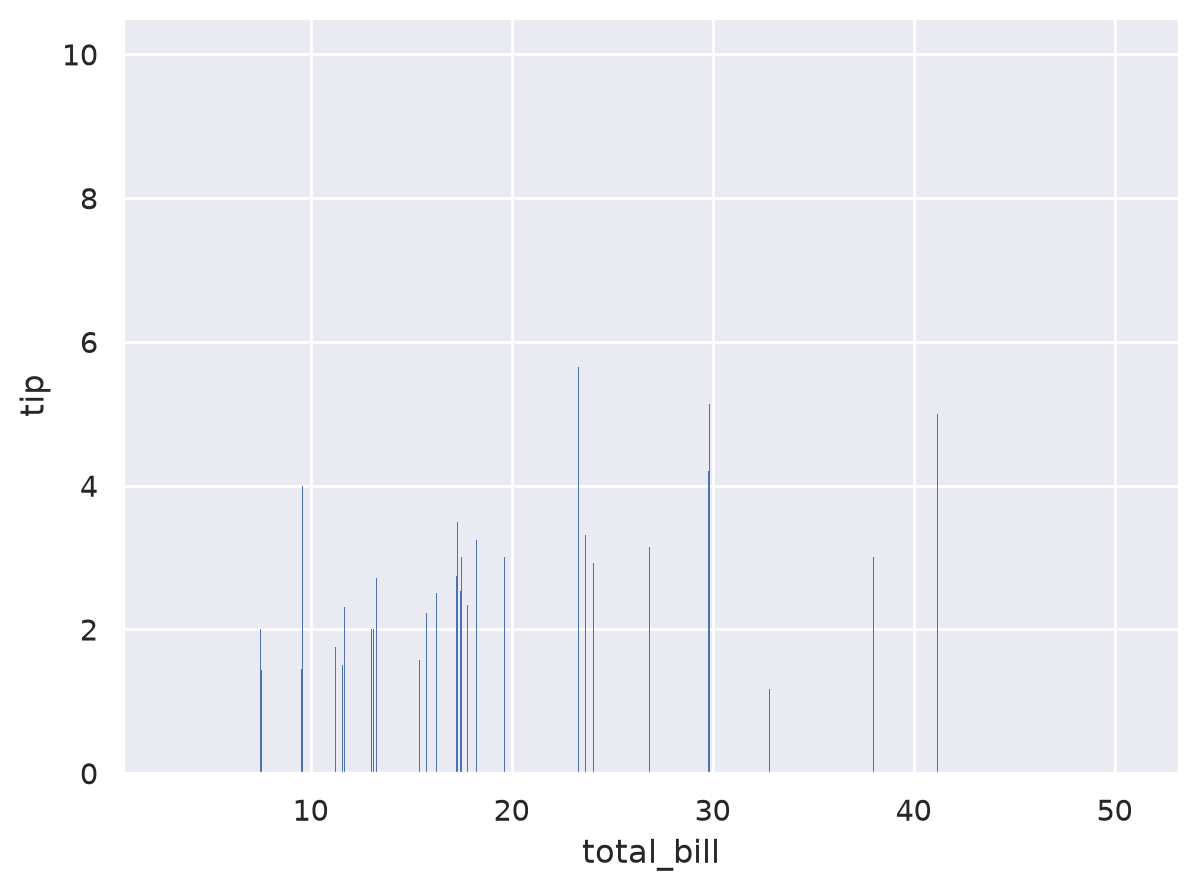

In [64]:
# Qué hace la marca "barras" (Bars)? 
tips = sns.load_dataset("tips")
(
    so.Plot(tips, "total_bill", "tip") # notar que no es necesario poner "data=...", "x=...", "y=..."
    .add(so.Bar())
)

En el anterior caso no es una buena visualización.

Probamos un ejemplo más sencillo

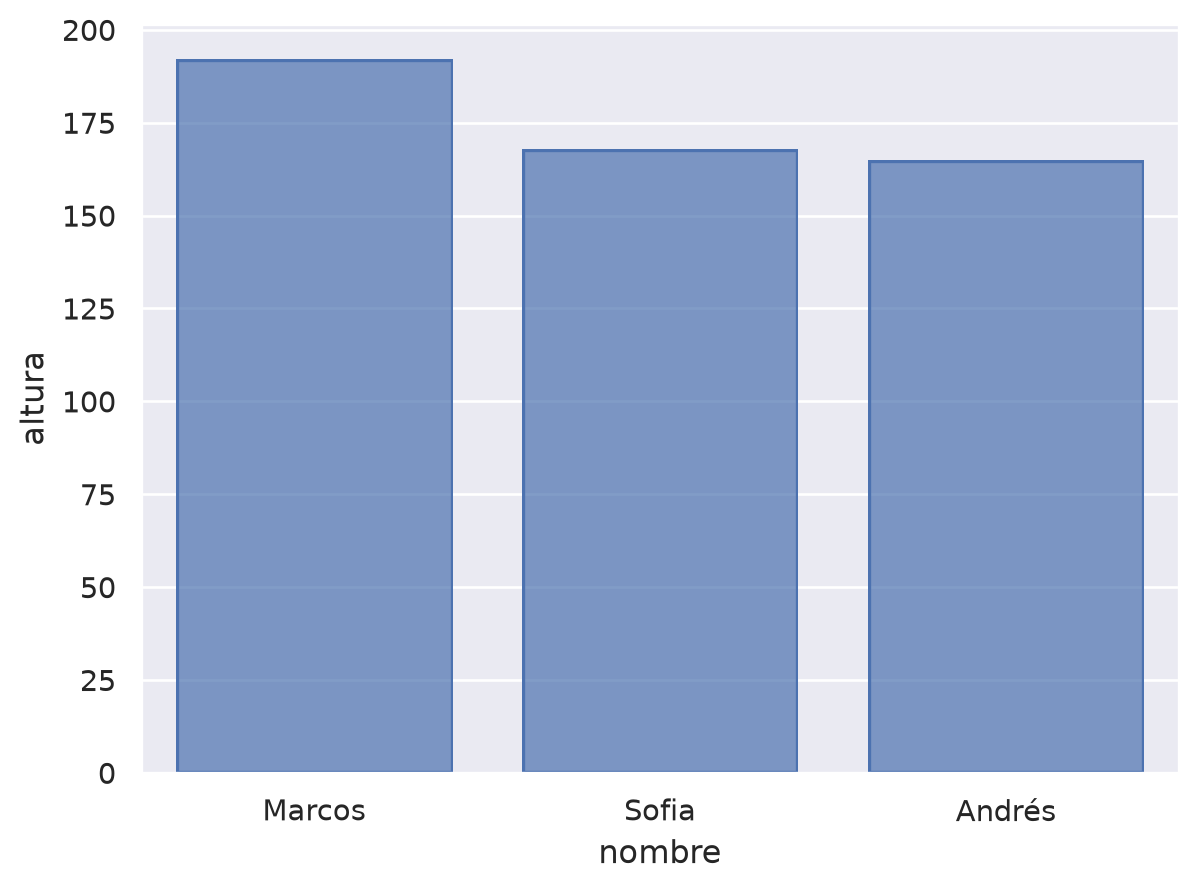

In [65]:
personas = pd.DataFrame({'nombre':['Marcos', 'Sofia', 'Andrés'], 'altura':[192, 168,165]})
(
    so.Plot(personas, "nombre", "altura")
    .add(so.Bar())
)

In [66]:
# La variable x puede también corresponder a valores numéricos discretos.
# Graficamos la cantidad total de vuelos por año.

flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


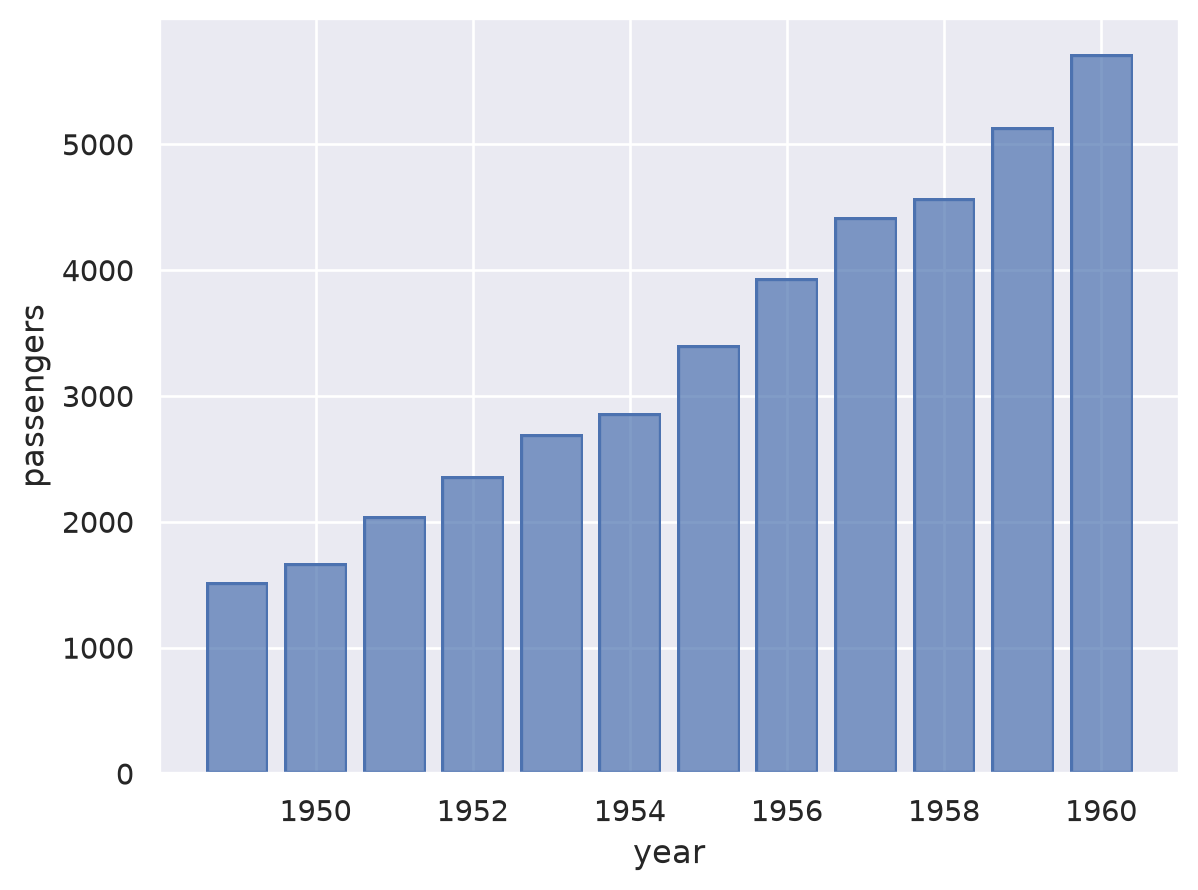

In [67]:
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Bar(), so.Agg("sum"))
)

## Gráfico de barras de frecuencias
El último gráfico de barras vemos la cantidad de pasajero en función del año.
En ese caso las cantidades por mes ya estaban calculadas y solo las sumamos.

Cuando tenemos todos los datos individuales, podemos agregarlos para hacer un gráfico de barras usando el método `hist`.

In [68]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Frecuencias de una variable categórica

Tenemos una base de datos con información de píngüinos y queremos saber cuántos pingüinos hay en cada isla.

No tenemos en la tabla ningún dato de población por isla, tenemos un renglon por cada pingüino, y para cada pingüino sabemos a qué isla pertenece.

In [71]:
# A mano 
islas = ['Biscoe', 'Dream', 'Torgersen']
poblacion = [168, 124, 52]
pinguinos_por_isla = pd.Series(poblacion, index=islas)
pinguinos_por_isla

Biscoe       168
Dream        124
Torgersen     52
dtype: int64

In [73]:
# Con una línea de pandas
pinguinos_por_isla = penguins.groupby("island").size()
pinguinos_por_isla

island
Biscoe       168
Dream        124
Torgersen     52
dtype: int64

In [74]:
pinguinos_por_isla.name = "poblacion"
pinguinos_por_isla.index.name = "isla"
display(pinguinos_por_isla)

isla
Biscoe       168
Dream        124
Torgersen     52
Name: poblacion, dtype: int64

In [75]:
# Esto no funciona, no podemos usar una series de Pandas como data
(
    so.Plot(data = pinguinos_por_isla, x = "isla", y = "poblacion")
    .add(so.Bar())
)

TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.Series'>.

**Pregunta:** ¿Podemos usar so.Plot() sin un DataFrame?

Sí, no necesariamente tenemos que indicar _data_, _x_ e _y_ al definir el Plot().

Podemos usar series de Pandas o arrays para x e y.

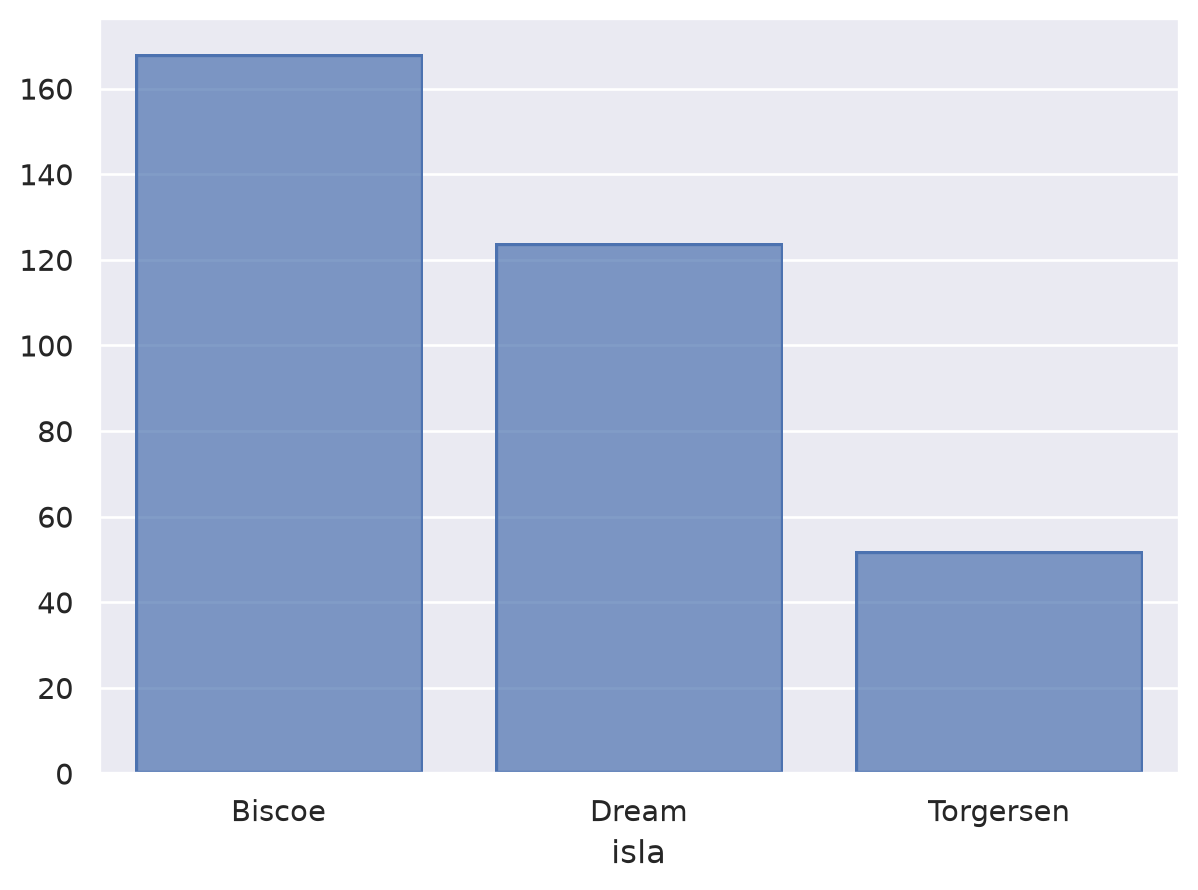

In [79]:
 # Pero podemos indicar series para x e y, y no especificar ninguna DataFrame
(
    so.Plot(x = pinguinos_por_isla.index, y = pinguinos_por_isla.values)
    .add(so.Bar())
)

### Frecuencias usando `so.Hist()`
Ahora usamos las funciones de so.Plot() para agregar los datos y realizar el histograma.

No necesitamos nosotros contar "a mano" cuántos pingüinos hay en cada isla.

In [80]:
# Repasamos los datos
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [81]:
# La variable "island" es una variable categórica, con tres valores distintos.
penguins["island"].unique()

<StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str

Contamos cuántas veces se repite cada uno de los tres valores.

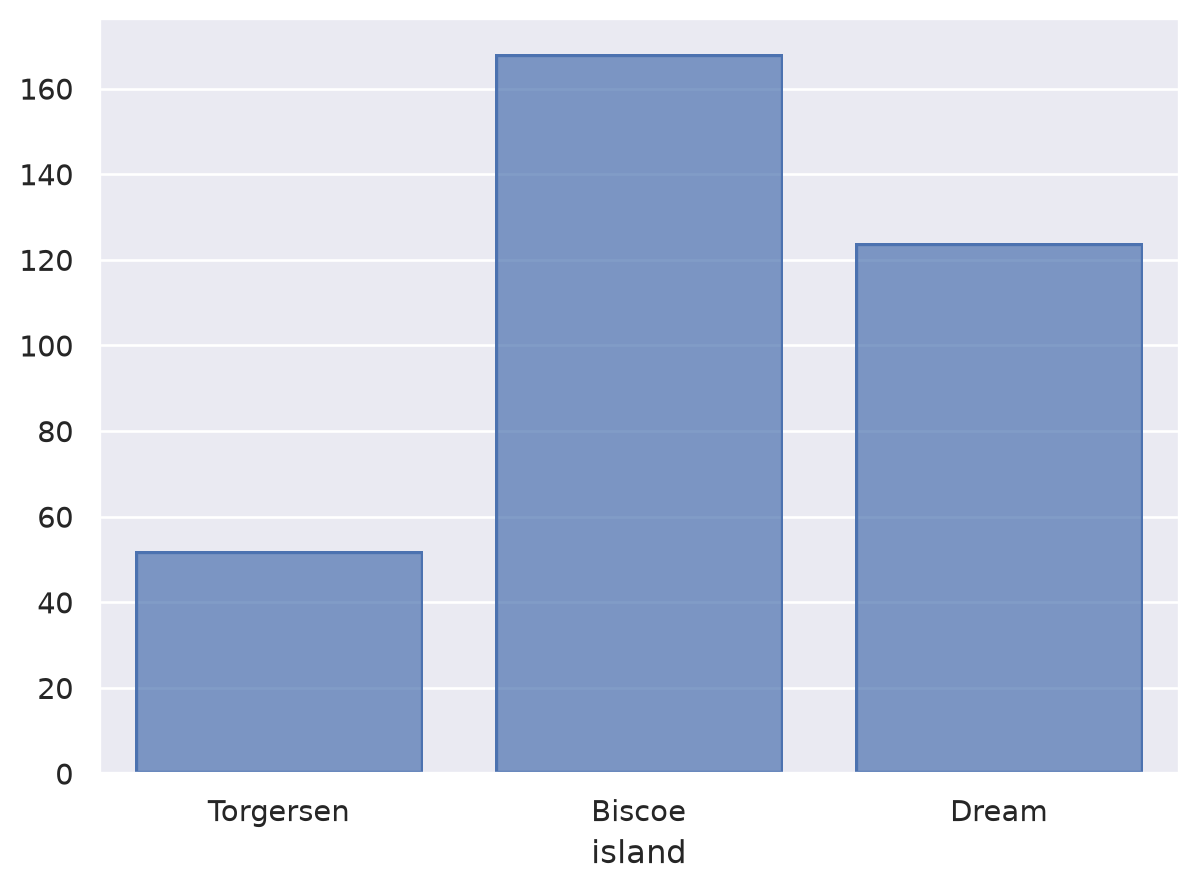

In [82]:
# Hay que asignar una variable y?
(
    so.Plot(data = penguins, x = "island")
    .add(so.Bar(), so.Hist())
)

### Histogramas (frecuencias de una variable numérica)

**Ejercicio.** Realizar en el cuaderno un histograma de cuatro barras para los siguientes datos:
$$
edades = \{20,28,18,10,50,55,70,75,80,76,82\}
$$

Verificar el gráfico en Python.


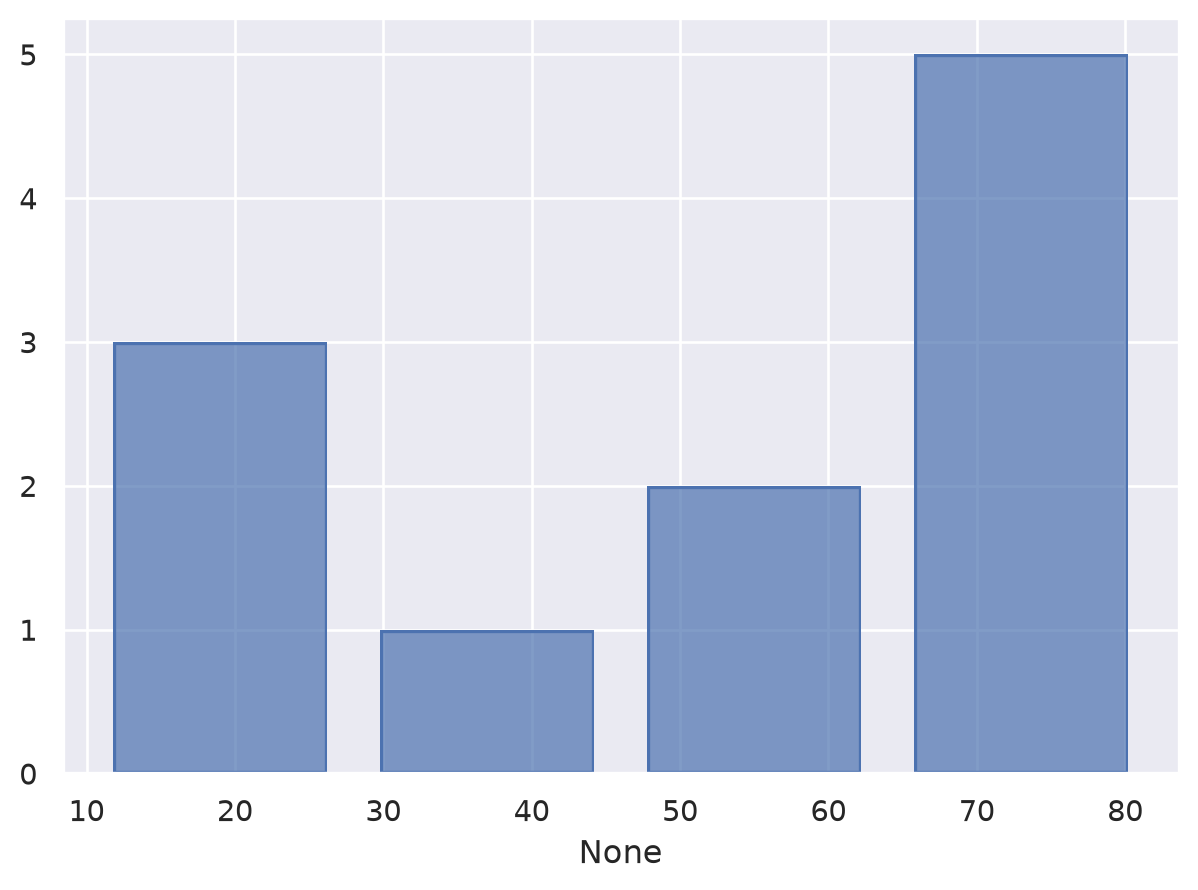

In [83]:
edades = pd.Series([20,28,18,10,50,55,70,75,80,76,82])
(
    so.Plot(x = edades)
    .add(so.Bar(), so.Hist(bins = 4))
)

Para histogramas de una variable continua es más común que no haya tanto espacio entre las barras.

Para eso usamos `Bars` en lugar de `Bar`.

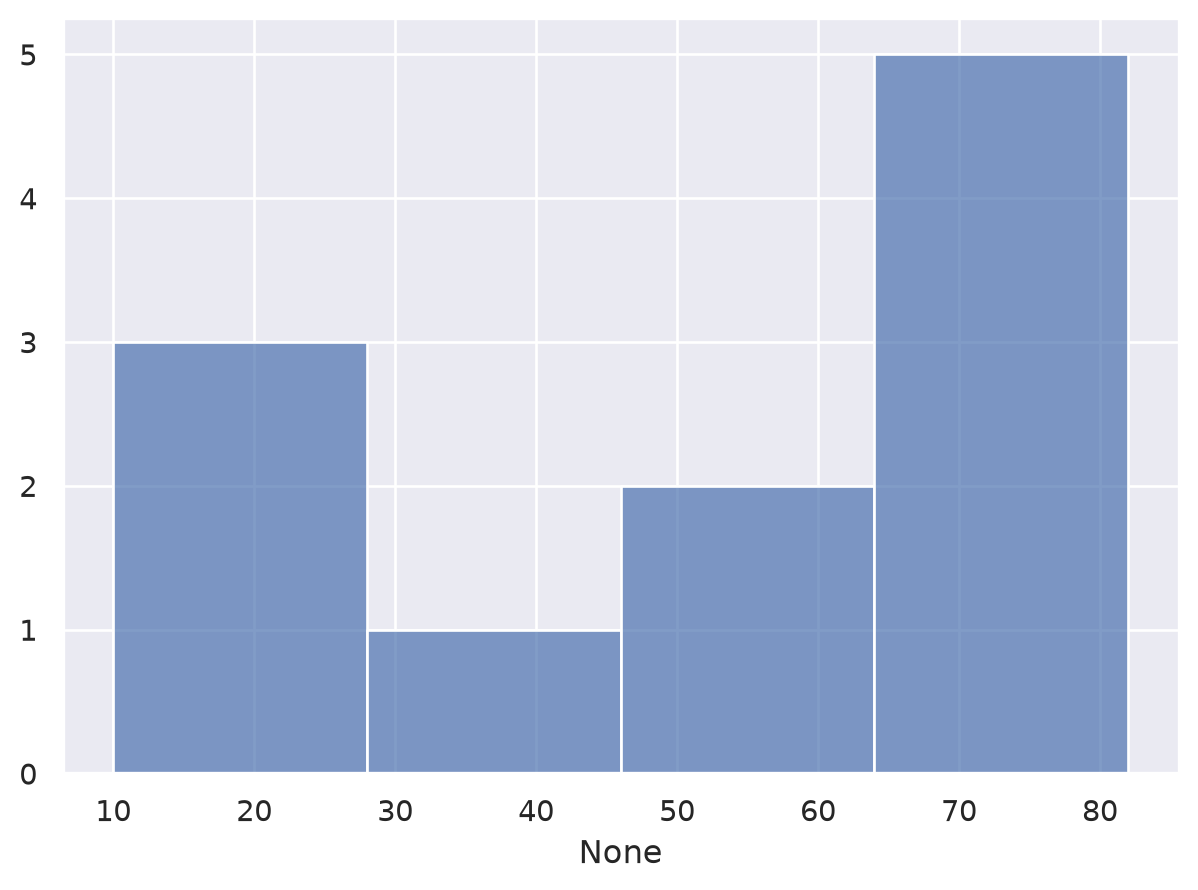

In [84]:
edades = pd.Series([20,28,18,10,50,55,70,75,80,76,82])
(
    so.Plot(x = edades)
    .add(so.Bars(), so.Hist(bins = 4))
)

### Histrogramas y distribución de una variable

Los histogramas nos sirven para analizar la distribución de valores observados de una variable.

**Ejemplo:** ¿Cuánto pesa un pingüino?

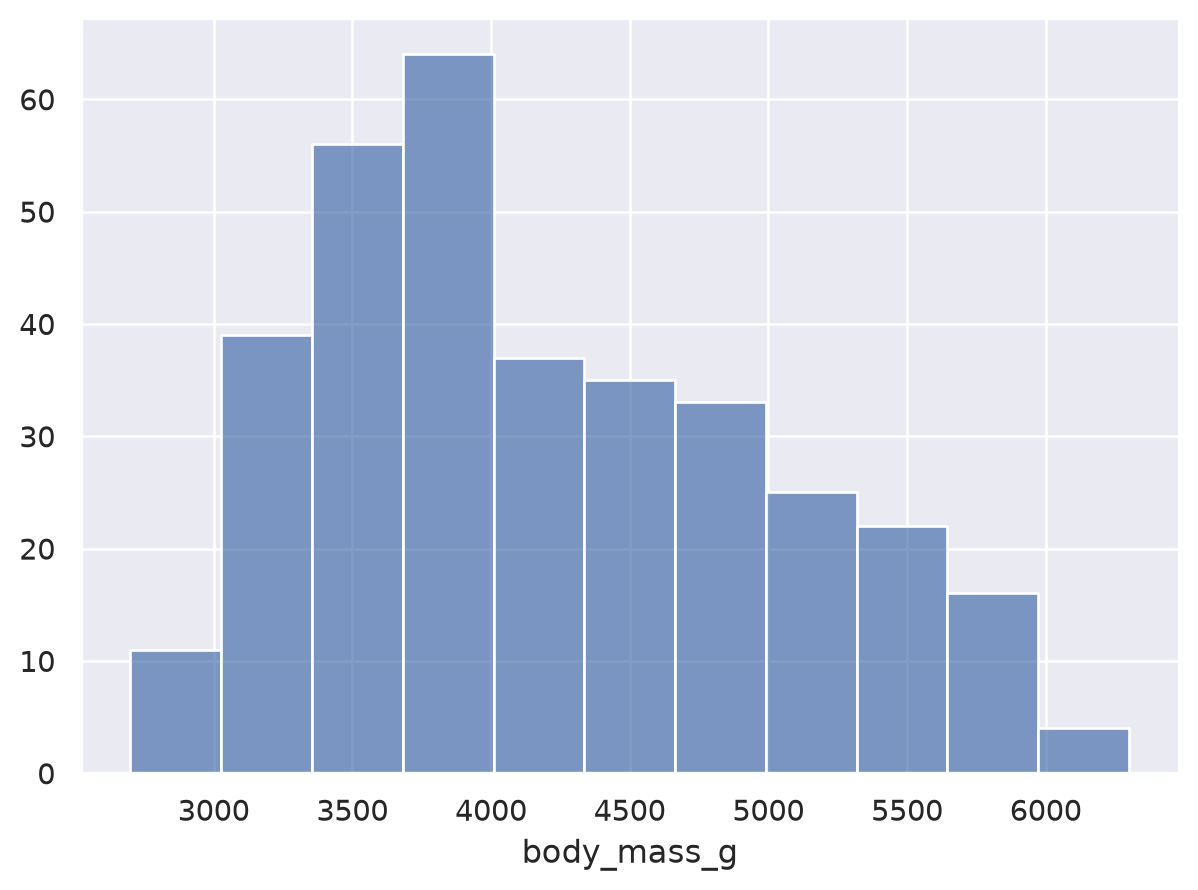

In [85]:
# Queremos ver cuántos pingüinos hay en distintos rangos de peso.
(
    so.Plot(data = penguins, x = "body_mass_g")
    .add(so.Bars(), so.Hist())
)

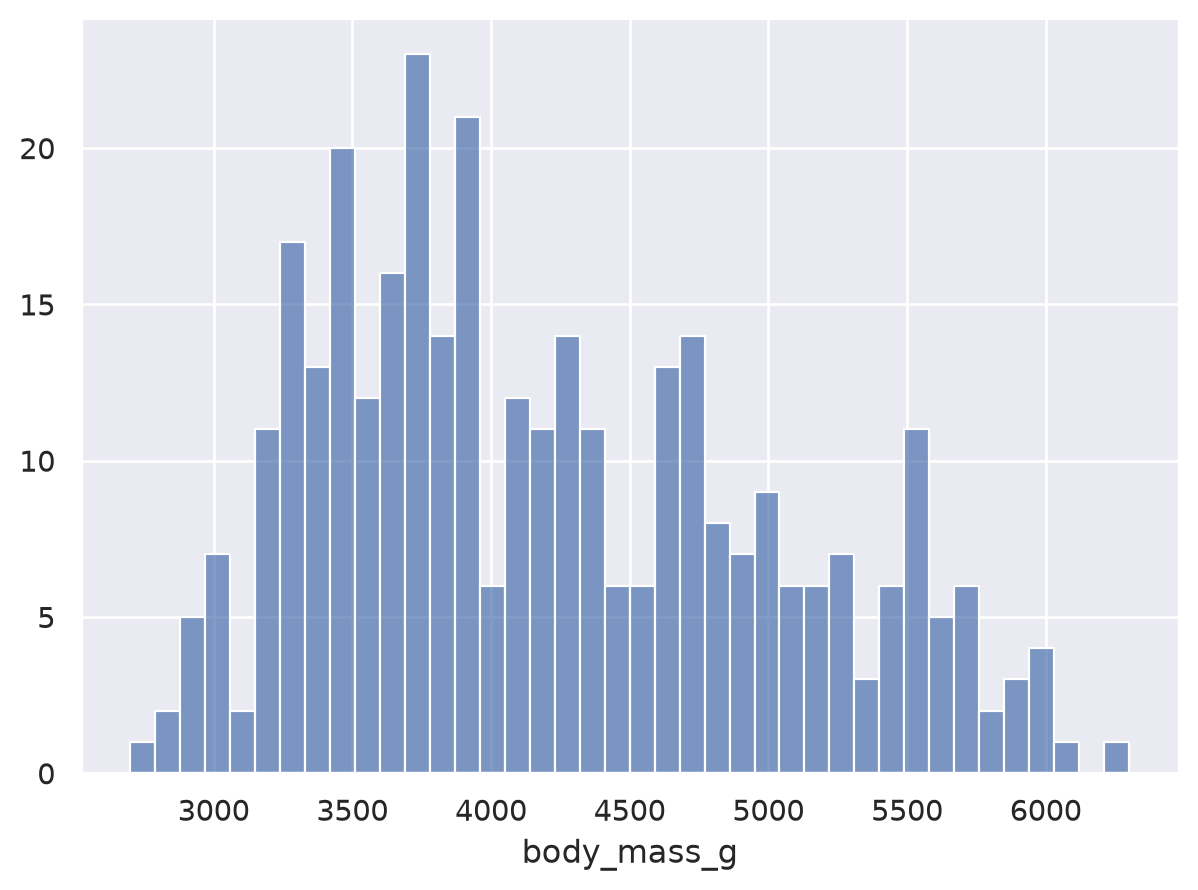

In [86]:
# Podemos cambiar la cantidad de intervalos. 
# Si tomamos muy pocos intervalos no vamos a poder distinguir los valores.
# Si tomamos muchos intervalos, van a quedar muy desagregados y será difícil comparar distintos intervalos.
(
    so.Plot(data = penguins, x = "body_mass_g")
    .add(so.Bars(), so.Hist(bins = 40))
)

### **Ejercicio** 
En el datasets de propinas, agregar una columna de "porcentaje" y realizar un histograma que permita visualizar cuánto dejan usualmente los comensales de propina.

In [87]:
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [88]:
tips["porcentaje"] = (tips["tip"] / tips["total_bill"]) * 100
tips

,total_bill,tip,sex,smoker,day,time,size,porcentaje
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


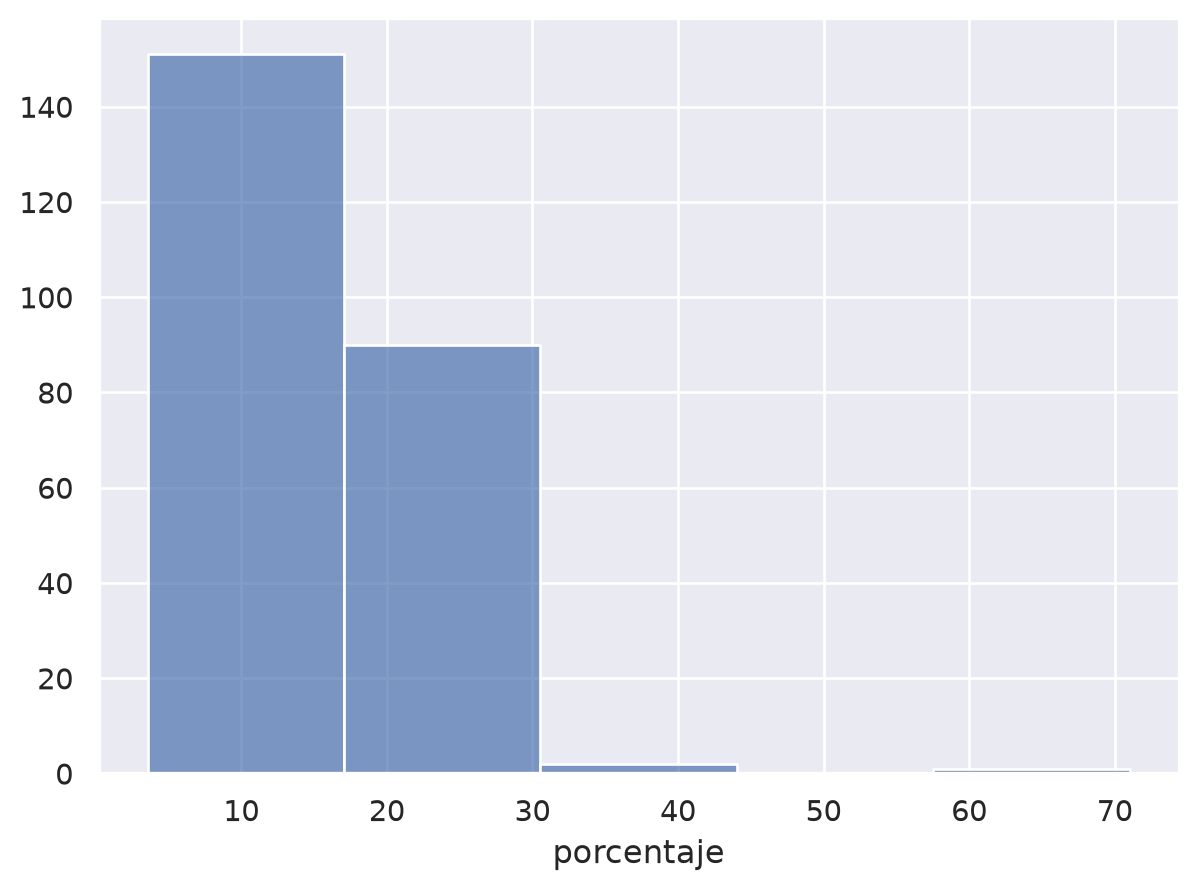

In [95]:
(
    so.Plot(data = tips, x = "porcentaje")
    .add(so.Bars(), so.Hist(bins=5))
)

Se deja usualmente el 10% de la cuenta de propina.

## Box plot

### Ejercicio
Realizar en el cuaderno un grafico boxplot para los siguientes datos:
$$
respuestas = \{10, 15, 20, 24, 30, 50, 54, 60, 62, 70, 100, 105\}
$$

Verificar el gráfico en Python.

En Seaborn Objects no tenemos la opción de realizar box plots. Podemos hacerlos utilizando `seaborn.boxplot()`. Los parámetros a pasar son similares.


In [96]:
respuestas = pd.Series([10, 15, 20, 24, 30, 50, 54, 60, 62, 70, 100, 105])

# Verificamos primero el cálculo de cuartiles
display(respuestas.quantile(.25, interpolation = "midpoint"))  # Primer cuantil
display(respuestas.quantile(.50))   # Segundo cuantil
display(respuestas.quantile(.75, interpolation = "midpoint"))  # Tercer cuantil

np.float64(22.0)

np.float64(52.0)

np.float64(66.0)

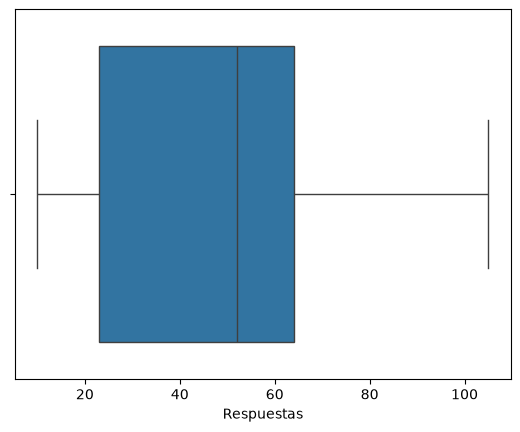

In [97]:
# Ahora realizamos el boxplot
(
    sns.boxplot(x = respuestas)
    .set(xlabel='Respuestas')
)
plt.show()

### Ejercicio.
1. Si agregamos a los datos un valor 110, será marcado como outlier en el gráfico?
2. Si cambiamos el ultimo valor (105) a un valor mas grande, a partir de qué valor pasaría a ser outlier en el gráfico?

Verificarlo en Python.

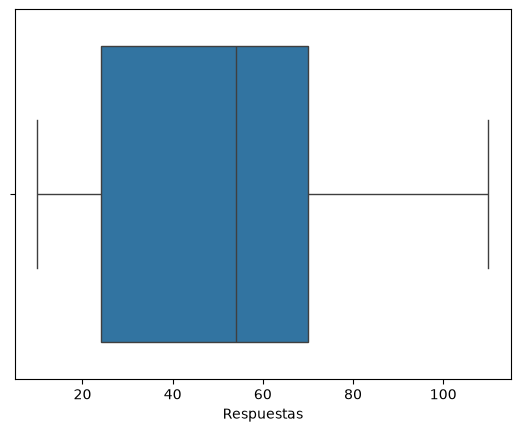

In [98]:
# 1)

respuestas = pd.Series([10, 15, 20, 24, 30, 50, 54, 60, 62, 70, 100, 105, 110])
respuestas.name = "Respuestas"
sns.boxplot(x = respuestas)
plt.show()


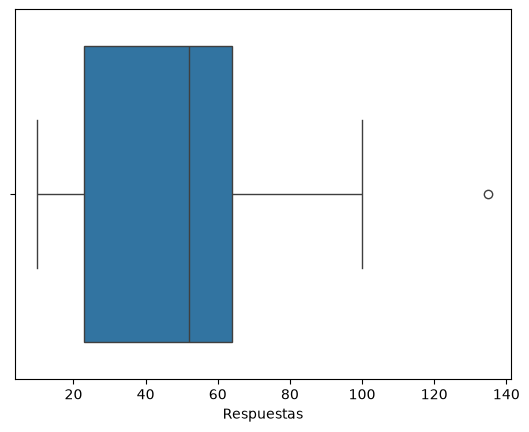

In [99]:
respuestas = pd.Series([10, 15, 20, 24, 30, 50, 54, 60, 62, 70, 100, 135])
respuestas.name = "Respuestas"
sns.boxplot(x = respuestas)
plt.show()

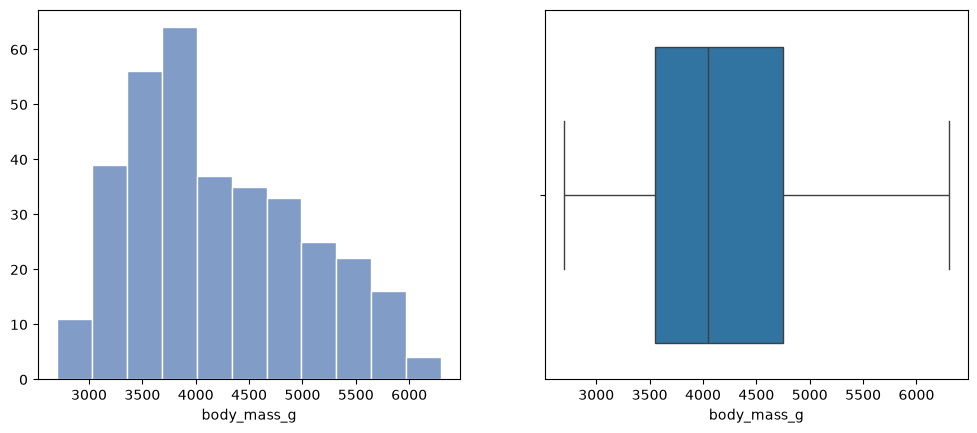

In [100]:
# Los mismos datos del histograma anterior del peso de los pingüinos, 
# podemos representarlos en un BoxPlot
fig, ax =plt.subplots(1,2)  # Utilizamos este código para crear una grilla de dos gráficos.
fig.set_figwidth(12)
(
    so.Plot(data = penguins, x = "body_mass_g")
    .add(so.Bars(), so.Hist())
    .on(ax[0]).plot()  # Colocamos el histograma en la primera casilla de la grilla.
)
sns.boxplot(penguins, x="body_mass_g", ax = ax[1])    # Colocamos el boxplot en la segunda casilla de la grilla.
plt.show()



### **Ejercicio** 
¿Qué conclusiones podemos sacar en base a este gráfico?

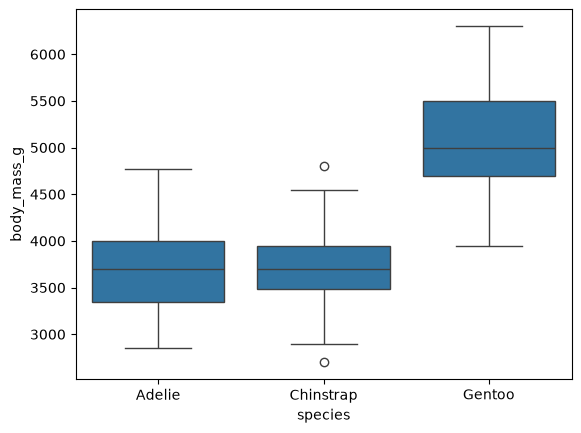

In [101]:
# Si queremos comparar distintos grupos de datos, podemos hacer boxplots para cada grupo
# Los mismos datos del histograma anterior, los representamos en un BoxPlot
sns.boxplot(data = penguins, x="species", y = "body_mass_g")
plt.show()

Las conclusiones que se peuden sacar son que los pinguinos de la especie Adelie y Chinstrap tienen un peso parecido. La especie Chinstrap tiene una menor variabilidad de pesos (aunque se pueden encontrar valores atipicos tanto por debajo del mínimo como por encima del máximo). Por otro lado, los pinguinos Gentoo pesan más que los pinguinos de las otras dos especies. 

### Cantidad de pasajeros por año

<Axes: xlabel='year', ylabel='passengers'>

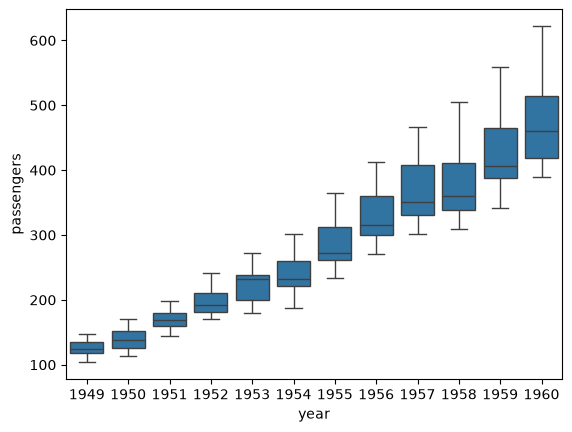

In [5]:
# También podemos representar la información de vuelos por mes utilizando boxplots.
sns.boxplot(data = flights, x = "year", y = "passengers")

### MPG

1) En el dataset mpg, utilizar gráficos BoxPlot para estudiar la eficiencia de los vehículos en función del lugar de origen. ¿Qué conclusiones puede obtener? 

In [8]:
mpg = sns.load_dataset("mpg")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


<Axes: xlabel='origin', ylabel='mpg'>

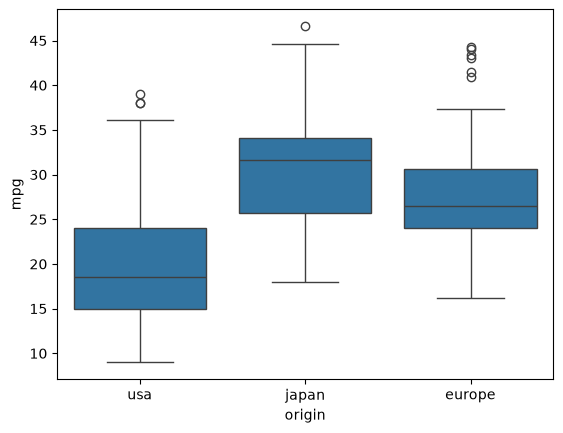

In [9]:
sns.boxplot(data = mpg, x = "origin", y = "mpg")

La principal conclusión clara es que los vehiculos de origen japones son los mas eficientes, seguidos por los europeos y dejando últimos a los estadounidenses (este tiene modelos que igualan o hasta superan a los japoneses o europeos, pero no son la mayoría)

2) Utilizar gráficos BoxPlot para comparar la eficiencia de los autos segun el año del modelo, utilizando solo auto modelo 1970, 1975 y 1980.

In [13]:
datos70_75_80 = mpg[mpg["model_year"].isin([70, 75, 80])]
datos70_75_80

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
333,32.7,6,168.0,132.0,2910,11.4,80,japan,datsun 280-zx
334,23.7,3,70.0,100.0,2420,12.5,80,japan,mazda rx-7 gs
335,35.0,4,122.0,88.0,2500,15.1,80,europe,triumph tr7 coupe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra


<Axes: xlabel='model_year', ylabel='mpg'>

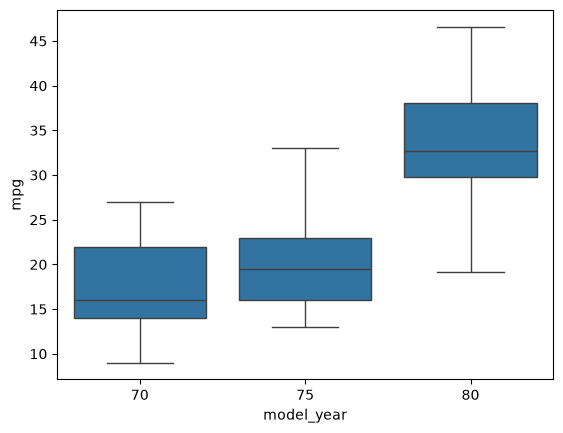

In [14]:
sns.boxplot(data = datos70_75_80, x = "model_year", y = "mpg")

En este gráfico puedo ver como hay un salto en la eficiencia de los autos del 75 al 80. Entre el 70 y el 75 la gran mayoría de los autos tenían eficiencias parecidas, pero recién en el 80 se ve un aumento importante.